# Engenharia de Características para a Aprendizagem Computacional
## Trabalho Prático 1
Trabalho realizado por:
- Beatriz Fernandes
- Bernardo Mendes
- Diana Martins

### Dataset
O Dataset utilizado é o FORTH-TRACE benchmark. O mesmo contém dados recolhidos de 5 sensores, incluindo sensores de aceleração, velocidade angular e variação do campo magnético, quer da parte superior, quer da parte inferior, do corpo.

### Bibliotecas Utilizadas

In [10]:
import numpy as np
import csv
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib.cm as cm
import pandas as pd

### Exercício 2
#### 1. Carregamento dos dados
Os dados foram carregados a partir dos ficheiros CSV disponibilizados no dataset. À medida que os dados foram sendo adicionados a um array auxiliar, foi também adicionada uma coluna com o ID do participante, de forma a manter essa informação para os passos seguintes.

In [ ]:
import numpy as np
import csv
import os

def load_data(dataset_root='../FORTH_TRACE_DATASET', save_path='all_data.npy'):
    # Se o arquivo já existe, lê direto
    if os.path.exists(save_path):
        print("Carregando dados do arquivo salvo...")
        return np.load(save_path)
    
    print("Lendo dados dos CSVs...")
    data_rows = []
    for part_id in range(15):
        dataset_path = f"{dataset_root}/part{part_id}"
        participant_id = part_id
        for dev_id in range(1, 6):
            csv_file = f"{dataset_path}/part{part_id}dev{dev_id}.csv"
            with open(csv_file, 'r', newline='') as f:
                reader = csv.reader(f, delimiter=',')
                for row in reader:
                    arr = np.array(row, dtype=float)
                    new_row = np.hstack((np.array([participant_id], dtype=float), arr))
                    data_rows.append(new_row)

    data = np.vstack(data_rows)
    
    # Salva em .npy para carregar rápido na próxima vez
    np.save(save_path, data)
    print(f"Dados salvos em {save_path}")
    
    return data

# Usar a função
data = load_data()
print(data[:5])


[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.0134e+00  5.0589e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7963e+00  9.3742e+00  2.4460e+00 -1.5618e+00
  -6.6165e-01  5.9730e-01 -3.4274e-01  5.7631e-01  1.0000e+00  5.2542e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.8696e+00  9.3000e+00  2.3514e+00 -1.1877e+00
  -1.2841e+00  1.4212e-01 -3.4476e-01  5.9639e-01  1.0156e+00  5.4495e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7961e+00  9.3624e+00  2.4584e+00 -5.8399e-01
  -2.0334e+00  4.2912e-01 -3.2863e-01  6.2249e-01  1.0156e+00  5.6448e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.6768e+00  9.3506e+00  2.4685e+00 -3.7050e-01
  -1.3647e+00  3.7194e-01 -3.3669e-01  6.2048e-01  1.0245e+00  5.8401e+02
   1.0000e+00]]


### Exercício 3
Análise e tratamento de outliers: o objetivo será identificar e tratar outliers usando diferentes abordagens univariável e multivariável. Para o efeito iremos utilizar os módulos dos vectores aceleração, giroscópio e magnetómetro. Seja
$$ \vec{t} = (tx, ty, tz) $$
o vector aceleração, giroscópio e magnetómetro. O respetivo módulo é determinado recorrendo:
$$ ||\vec{t}|| = \sqrt{tx^2 + ty^2 + tz^2} $$

### Exercício 3.1
Elabore uma rotina que apresente simultaneamente o boxplot de cada atividade (coluna 12 – eixo horizontal) relativo a todos os sujeitos e a uma das seguintes variáveis transformadas: módulos dos vectores de aceleração, giroscópio e magnetómetro. Sugere-se o uso da biblioteca matplotlib, por exemplo, a classe matplotlib.pyplot.boxplot.

In [ ]:
def module_boxplots(data, sensor):
    if sensor == 1:
        c = (2,3,4)
        label = 'Acceleration'
    elif sensor == 2:
        c = (5,6,7)
        label = 'Gyroscope'
    elif sensor == 3:
        c = (8,9,10)
        label = 'Magnetometer'
    else:
        raise ValueError("sensor must be 1, 2, or 3")
    
    # módulo = sqrt(x^2 + y^2 + z^2)
    mod = np.sqrt((data[:, c] ** 2).sum(axis=1))
    
    #extrai as informações 
    device = data[:, 1].astype(int)
    activities = data[:, 12].astype(int)
    unique_activities = np.unique(activities)
    unique_devices = np.unique(device)
    
    # Cria um gráfico por dispositivo
    for dev in unique_devices:
        plt.figure(figsize=(10, 5))
        boxplot_data = []
        
        # Para cada atividade, vê os módulos correspondentes a este dispositivo
        for act in unique_activities:
            mask = (device == dev) & (activities == act)
            mods_from_act = mod[mask]
            boxplot_data.append(mods_from_act)
        
        plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)
        plt.xlabel('Activity')
        plt.ylabel(f'{label} Module')
        plt.title(f'{label} Module by Activity — Device {dev}')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


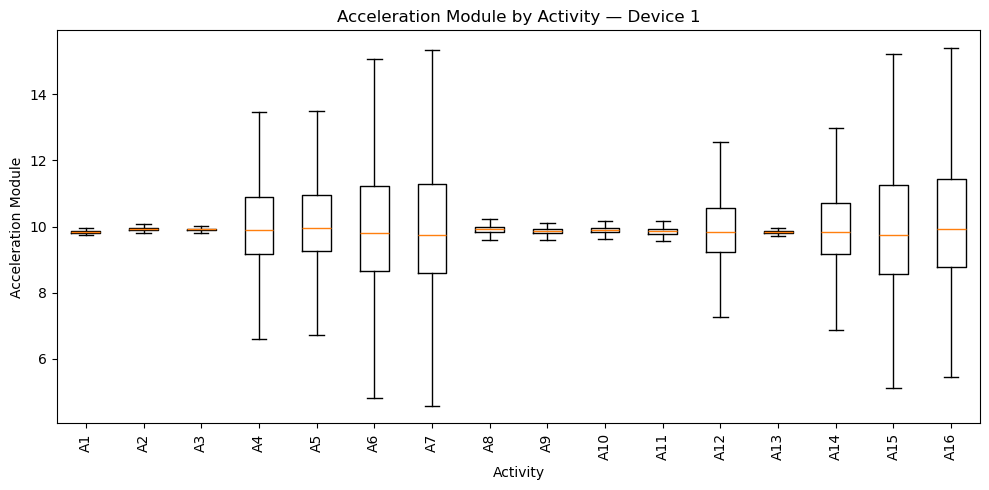

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


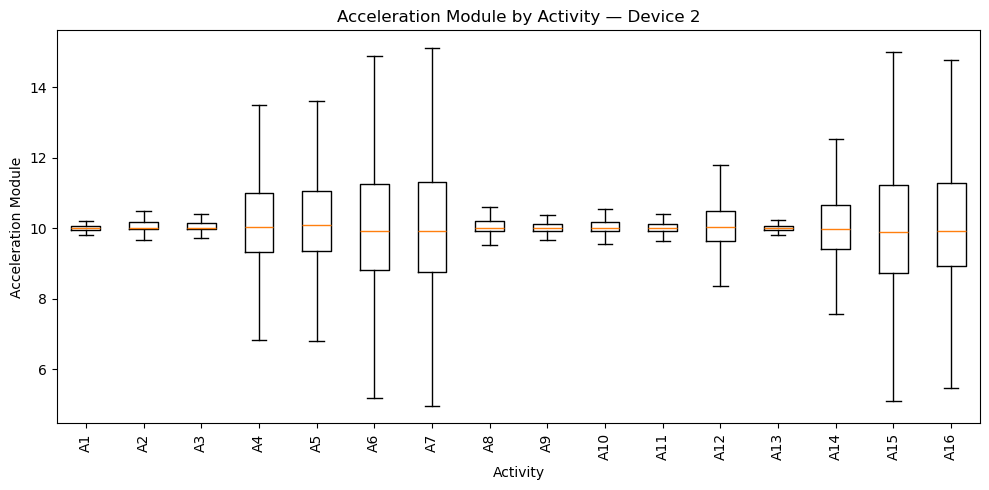

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


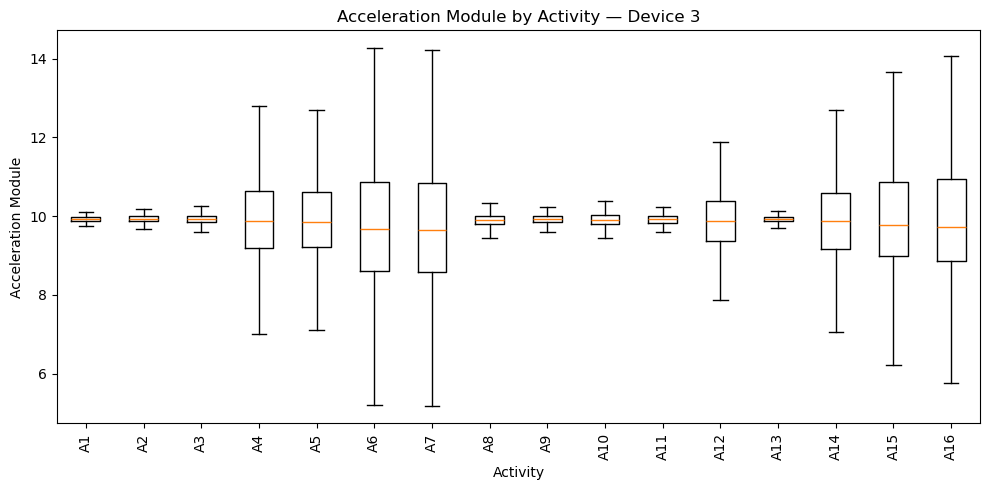

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


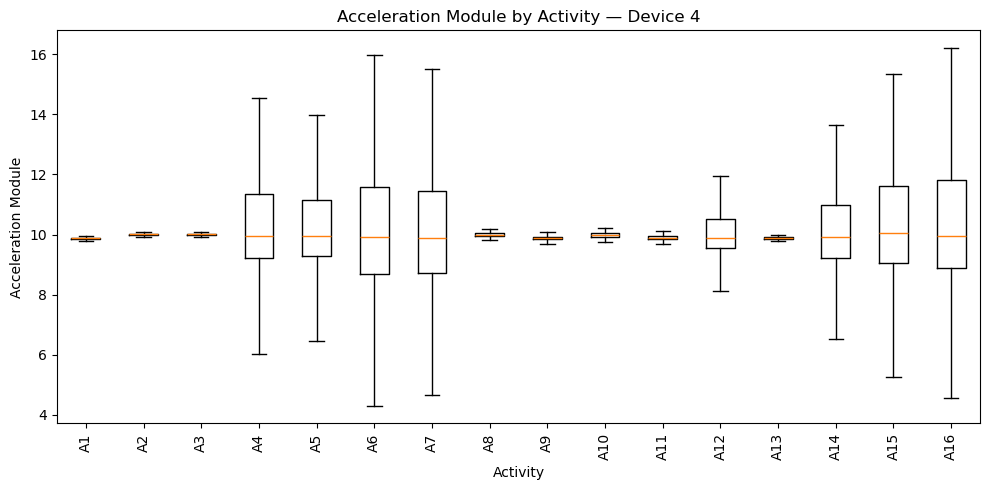

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


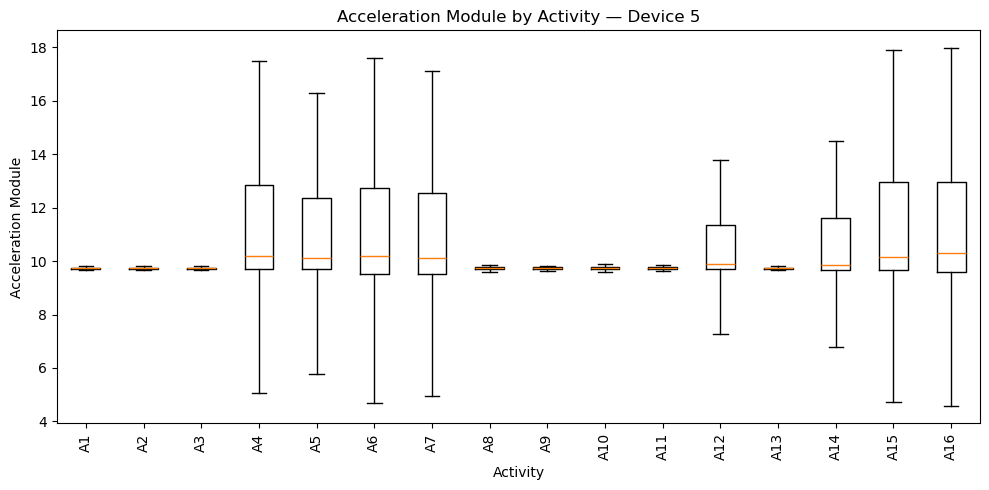

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


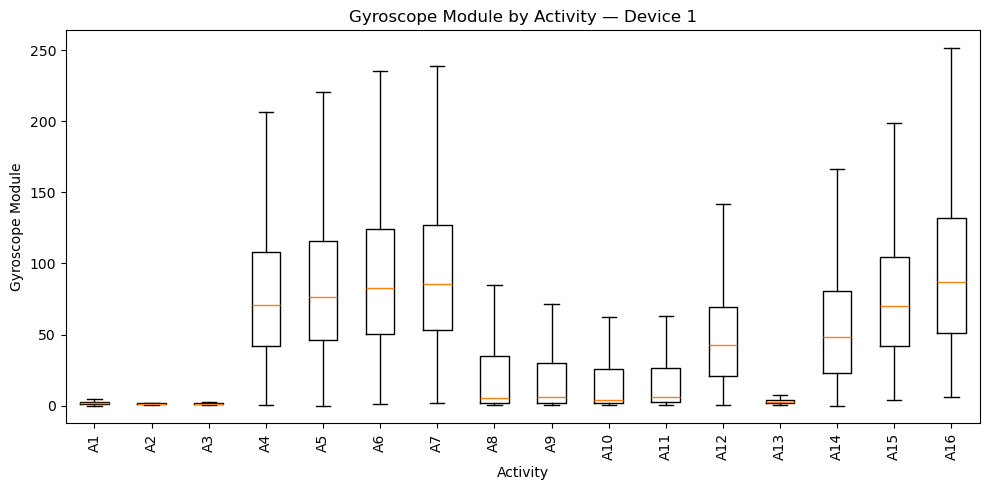

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


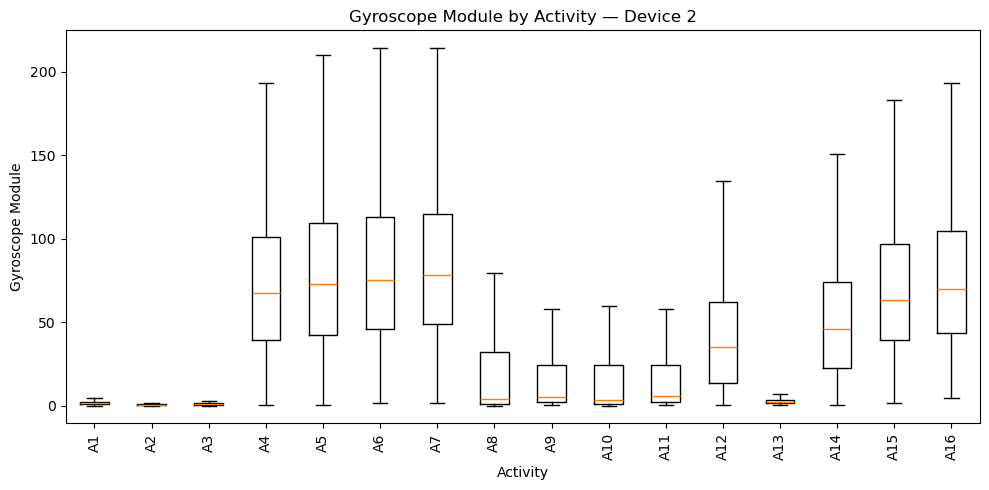

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


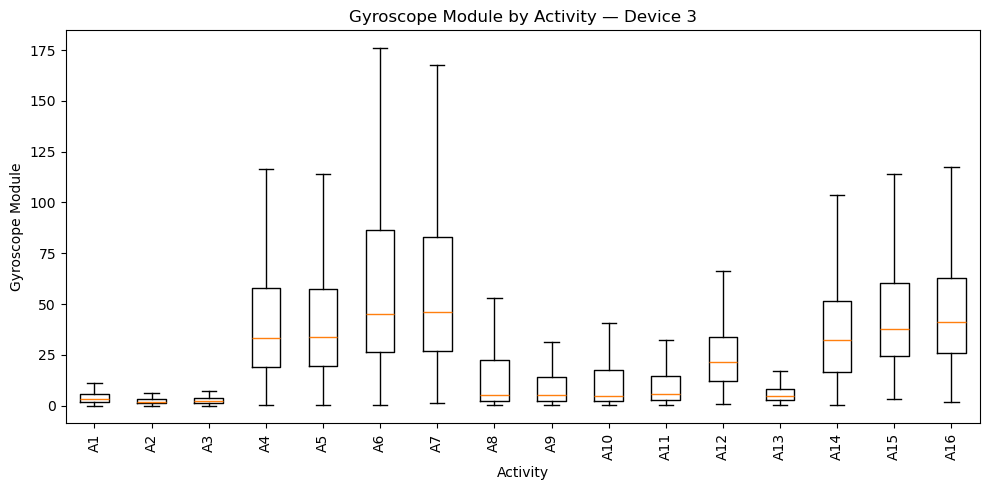

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


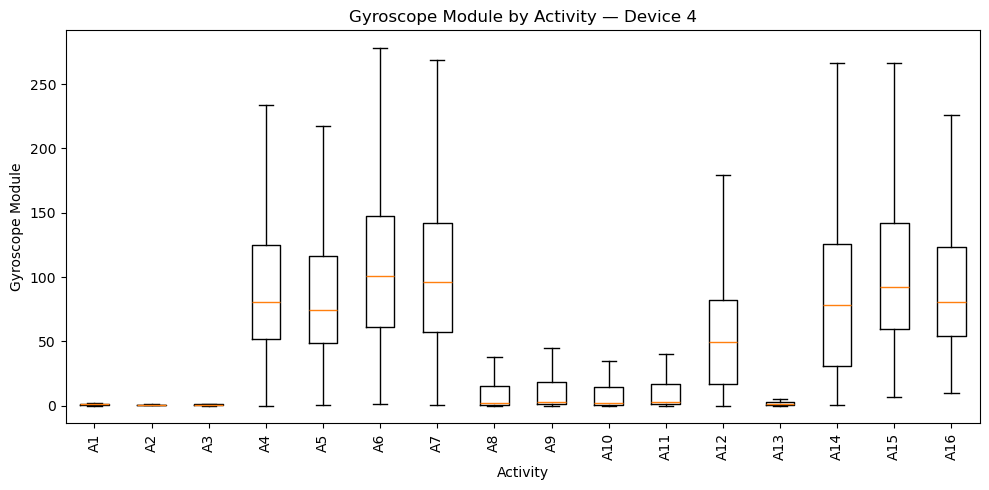

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


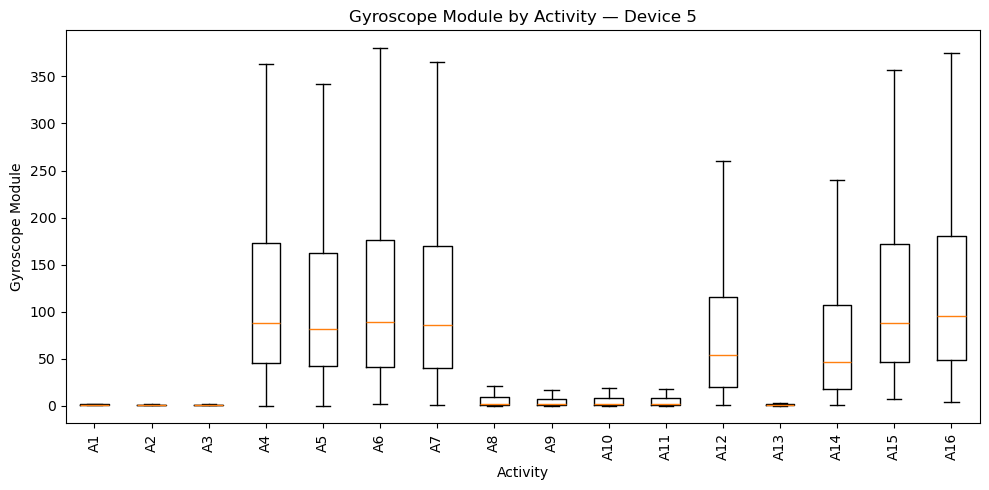

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


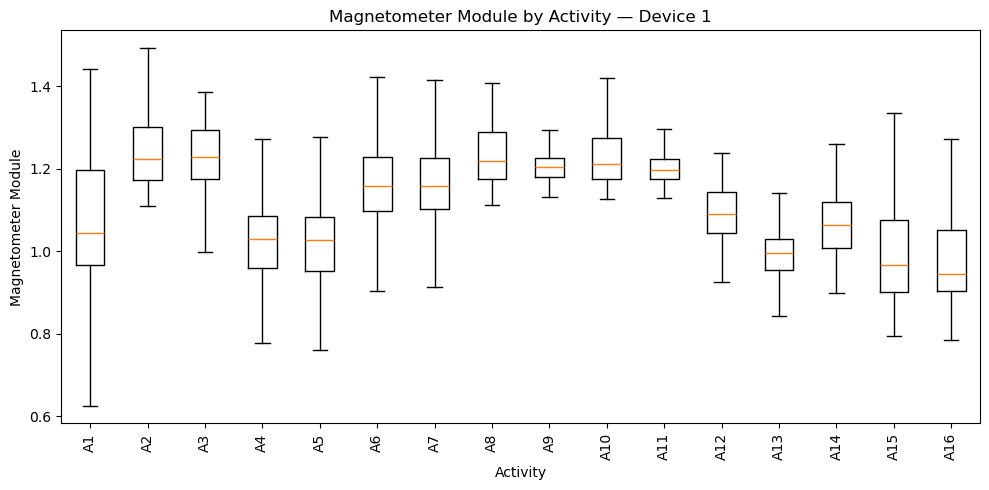

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


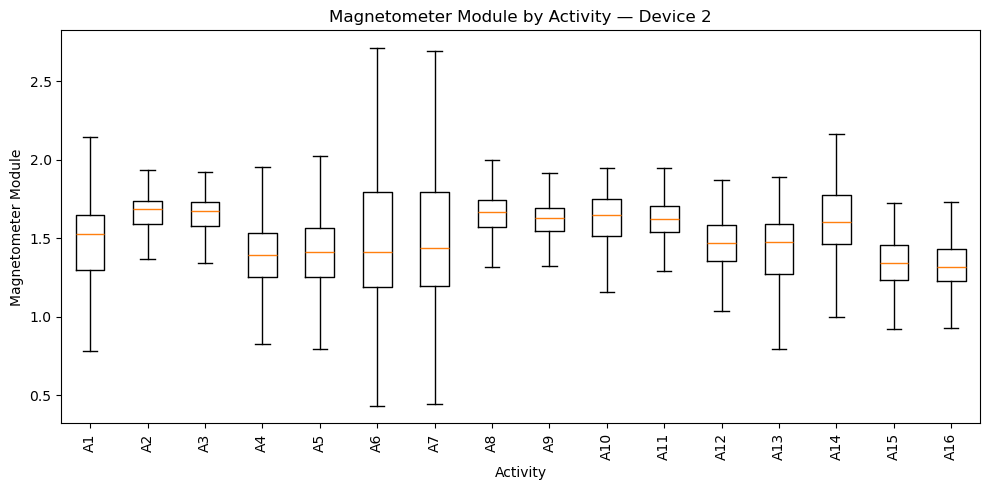

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


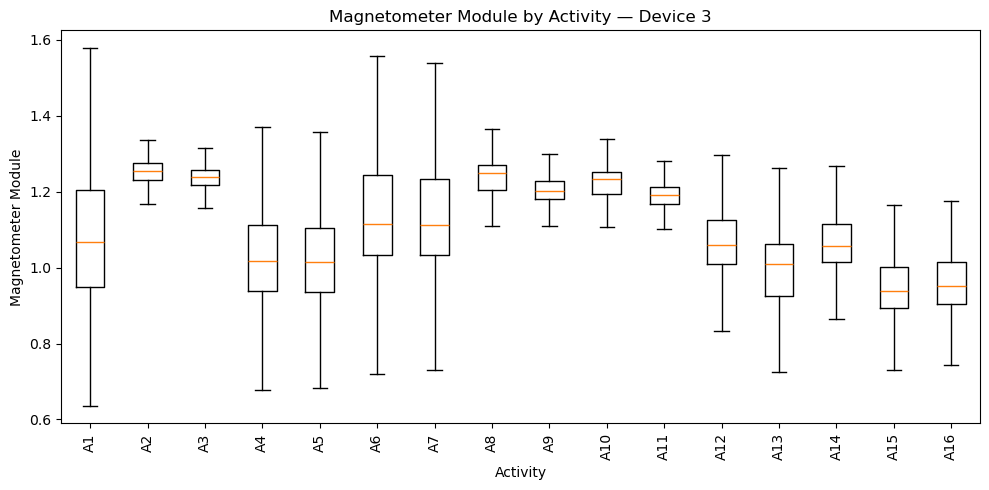

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


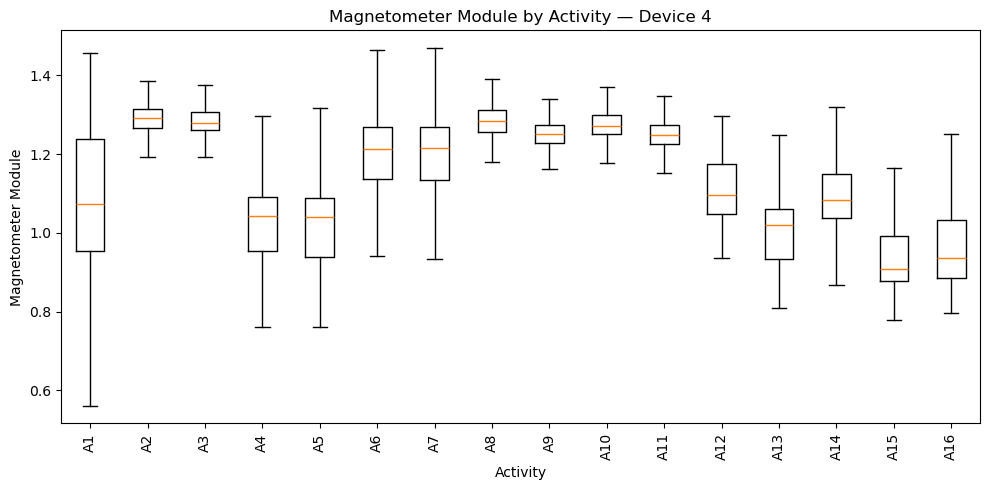

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


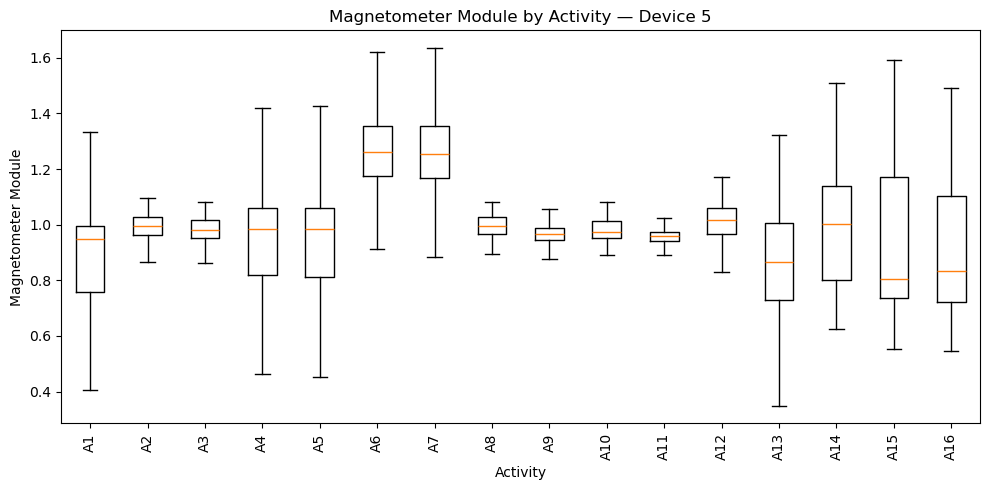

In [5]:
module_boxplots(data, 1)
module_boxplots(data, 2)
module_boxplots(data, 3)

  ## Observações:
  ### Geral:
  Existe uma grande presença de outliers em todos os sensores, o que é visível em praticamente todas as atividades. Sugere que os movimentos humanos contêm variações extremas? É necessário aprofundar a análise para perceber se estes outliers são de facto variações extremas ou se são erros de medição.
 
  ### Aceleração:
  #### Módulo Aceleração:
  - As atividades estáticas (1, 2, 3) apresentam uma mediana próxima de 10, que correspondem, aproximadamente, à aceleração da gravidade (~9.81 m/s²), com uma variabilidade muito reduzida(caixas pequenas). Isto indica que o corpo está maioritariamente em repouso.
  - As atividades dinâmicas (4,5,6,7) apresentam maior dispersão. Isto reflete a constante variação de aceleração inerente a estas atividades.
  - DISPOSITIVO 1: atividades dinâmicas como caminhar (A4, A5) e subir escadas (A6, A7) apresentam módulos mais elevados, enquanto atividades estáticas (A1, A2, A3) mostram valores baixos. Existe uma boa distinção.
  - DISPOSITIVO 2: Padrão similar ao pulso esquerdo.
  - DISPOSITIVO 3: Valores geralmente mais baixos comparado aos pulsos, refletindo menor dispersão.
  - DISPOSITIVO 4: Atividades envolvendo locomoção mostram os maiores valores, especialmente subir escadas (A6, A7, A14-A16).
  - DISPOSITIVO 5: Módulos mais elevados durante caminhada e subida de escadas, com variações significativas entre atividades.
  #### Conclusão:
  - Os resultados são os esperados. O módulo da aceleração parece ser uma característica útil para distinguir entre atividades estáticas e dinâmicas.
  - A aceleração é mais pronunciada em membros em movimento (atividades 6,7,4,5,15 e 16) durante atividades dinâmicas uma vez que exigem mais esforço  e variação de velocidade. O peito apresenta os valores mais estáveis e baixos, indicando ser uma região com menos variação de movimento. Já as transições entre sentar/levantar são claramente identificadas pelos picos de aceleração.
  
  ### Giroscópio:
  #### Módulo Giroscópio:
  - Nas atividades estáticas, a mediana está praticamente a zero e a caixa é quase inexistente, indicando pouca ou nenhuma rotação. Sem movimento, não existe velocidade angular.
  - Nas atividades dinâmicas os valores de módulo e a dispersão são significativamente maiores, com outliers evidentes.
  - DISPOSITIVO 1: Atividades com movimento de braços (caminhar, falar gesticulando) mostram rotação significativa.
  - DISPOSITIVO 2:  Padrão similar ao pulso esquerdo, com algumas variações possivelmente relacionadas à dominância manual.
  - DISPOSITIVO 3: Valores moderados e é menos sensível a movimentos de extremidades.
  - DISPOSITIVO 4: Rotação elevada durante subida de escadas e caminhada.
  - DISPOSITIVO 5: Atividades de locomoção geram os maiores valores de rotação. Valores mais elevados de todos os dispositivos.
  #### Conclusão:
  - O giroscópio apresenta a distanção mais clara entre os dois tipos de atividade.
  - As atividades com maior rotação destacam-se novamente com as medianas e limites superiores mais elevados. 
  - O giroscópio é particularmente sensível a movimentos rotacionais durante transições entre posturas. Dispositivos nas pernas capturam melhor a rotação durante atividades de locomoção. Além disso, na atividade 5 e 7 (onde se observa um ligeiro aumento na rotação mediana em comparação com as atividades 4 e 6) sugere que o ato de falar possivelmente combinado com mais alguma coisa introduz uma componente rotacional ao movimento. 
  
  ### Magnetómetro:
  #### Módulo Magnetómetro:
  - Existe uma enorme quantidade de outliers nas atividades 6 (Climb Stair) e 7 (Climb Stair and talk). Esse fenómeno provavelmente não se deve ao movimento em si, mas sim ao facto de escadas conterem frequentemente estruturas metálicas (corrimões, vigas, etc.) que podem interferir com o sensor magnético.
  - DISPOSITIVO 1: Variações moderadas entre atividades, com padrões menos definidos que aceleração/giroscópio.
  - DISPOSITIVO 2: Comportamento similar ao pulso esquerdo.
  - DISPOSITIVO 3: Valores geralmente mais estáveis. É menos afetado por interferências localizadas.
  - DISPOSITIVO 4:Maior variação durante atividades que envolvem movimento significativo das pernas.
  - DISPOSITIVO 5: Padrões similares à perna superior, mas com algumas diferenças específicas por atividade. 
  #### Conclusão:
  - Ao contrário dos outros sensores, o magnetómetro não mostra uma distinção tão óbvia entre a maioria das atividades estáticas e dinâmicas. As medianas e os intervalos interquartis são relativamente semelhantes entre muitas das atividades. Mas em contrapartida, o magnetómetro pode ser um indicador de uma atividade relacionada com escadas, devido à quantidade de outliers observados.
  - Para a maioria das atividades, as caixas são relativamente compactas e as medianas não variam drasticamente. 
  


  #### Conclusão geral:
  - A análise confirma que a parte do corpo onde o sensor é colocado influencia drasticamente os dados. Sensores em extremidades (pulsos, pernas) capturam uma amplitude de movimento muito maior e mais variável, enquanto sensores no torso (peito) fornecem um sinal mais estável e consistente.
  - A omnipresença de outliers em todos os sensores e atividades, mas concentrada em contextos específicos (escadas para o magnetómetro; atividades dinâmicas para aceleração e giroscópio), sugere que a maioria destes pontos são, de facto, variações extremas genuínas do movimento humano e não simples erros de medição. Isto é particularmente evidente no dispositivo 5 (perna), onde a natureza do movimento gera naturalmente picos(ex: um passo mais brusco).
  - Os resultados estão de acordo com a intuição biomecânica. Atividades mais exigentes como subir escadas geram os sinais mais intensos. As transições são marcadas por picos e maior variabilidade. A fala acrescenta uma camada subtil de complexidade ao movimento, detetável nos dados do giroscópio.

- Em relação aos dispositivos conseguimos perceber que o pulsos são membros muito ativos, o peito uma vez que é uma região central e estável do corpo dá dados menos ruidosos (mudar isto). Já as pernas, quando se trata da parte superior é bom para atividades de locomoção, e a parte inferior é caracterizada por picos intensos devido à zona ser muito sensível.

### Exercício 3.2
Analise e comente a densidade de outliers existentes no dataset transformado, isto é, nos módulos dos vetores aceleração, giroscópio e magnetómetro para cada atividade (use somente os sensores do pulso direito). Observe que a densidade é determinada recorrendo:
$$ d = \frac{no}{nr} * 100 $$
em que no é o número de pontos classificados como outliers e nr é o número total de pontos.

In [43]:
def outliers_density(data, sensor):
    device_id = 2 #pulso direito
    device_data = data[data[:,1] == device_id]

    if sensor == 1:
        c = (2,3,4)
        label = 'Aceleration'
    elif sensor == 2:
        c = (5,6,7)
        label = 'Gyroscope'
    elif sensor == 3:
        c = (8,9,10)
        label = 'Magnetometer'
    else:
        raise ValueError("sensor must be 0, 1, or 2")
    
    
    sensor_data= device_data[:, c]
    magnitude= np.linalg.norm(sensor_data, axis=1)
    
    activities= device_data[:,12]
    unique= np.unique(activities)
    results= {}
    outlier_counts=[]
    
    print(f"\n=== {label} – Device {device_id} ===\n")
    
    for a in unique: 
        mag = magnitude[activities==a]
    
        #calcular os quartis para os outliers
        Q1= np.percentile (mag, 25)
        Q3= np.percentile (mag, 75)
        IQR= Q3-Q1
        lower_limit= Q1-1.5*IQR
        upper_limit= Q3+1.5*IQR
        
        #identificar outliers
        outliers = (mag < lower_limit) | (mag > upper_limit)
        
        #contar total de pontos e o número de outliers
        nr= len(mag)
        no= np.sum(outliers)
        
        #calcular a densidade de outliers 
        if nr > 0:
            density = (no / nr) * 100
        else:
            density = 0
        
        
        results[a] = {
            'density': density,
            'total_points': nr,
            'outliers_count': no
        }
        outlier_counts.append(no)
        
        #mostrar os resultados em percentagem
        print(f"Atividade {int(a)}: densidade = {density:.2f}% " f"({int(no)}/{int(nr)} pontos)")
        
    plt.figure(figsize=(10,5))
    plt.bar(unique, outlier_counts)
    plt.ylabel('Number of Outliers')
    plt.title(f'Number of Outliers – {label} (Device 2)')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()




=== Aceleration – Device 2 ===

Atividade 1: densidade = 4.20% (6624/157882 pontos)
Atividade 2: densidade = 0.22% (181/83968 pontos)
Atividade 3: densidade = 0.51% (417/81152 pontos)
Atividade 4: densidade = 3.53% (4941/139934 pontos)
Atividade 5: densidade = 3.48% (4951/142366 pontos)
Atividade 6: densidade = 5.17% (4616/89359 pontos)
Atividade 7: densidade = 4.51% (1977/43791 pontos)
Atividade 8: densidade = 15.44% (1028/6656 pontos)
Atividade 9: densidade = 19.80% (1115/5632 pontos)
Atividade 10: densidade = 15.32% (1020/6656 pontos)
Atividade 11: densidade = 18.32% (985/5376 pontos)
Atividade 12: densidade = 10.92% (416/3810 pontos)
Atividade 13: densidade = 4.79% (365/7620 pontos)
Atividade 14: densidade = 14.17% (540/3810 pontos)
Atividade 15: densidade = 4.93% (94/1905 pontos)
Atividade 16: densidade = 4.99% (95/1905 pontos)


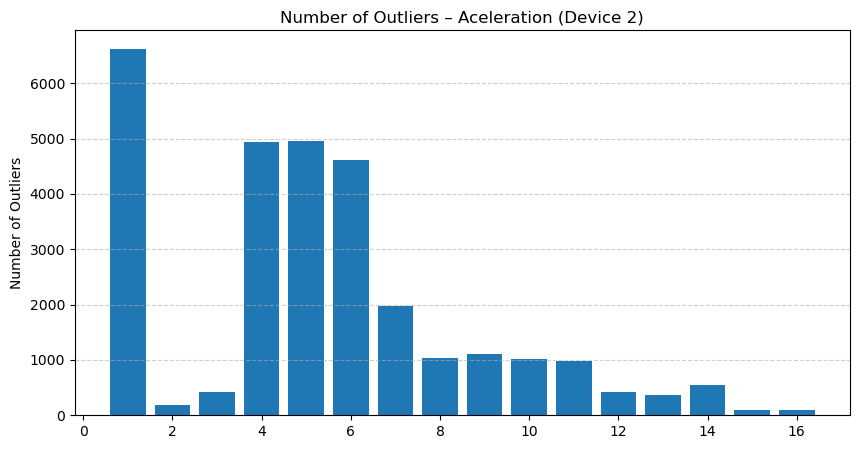


=== Gyroscope – Device 2 ===

Atividade 1: densidade = 9.48% (14975/157882 pontos)
Atividade 2: densidade = 6.65% (5581/83968 pontos)
Atividade 3: densidade = 9.12% (7399/81152 pontos)
Atividade 4: densidade = 1.62% (2268/139934 pontos)
Atividade 5: densidade = 1.43% (2033/142366 pontos)
Atividade 6: densidade = 1.50% (1339/89359 pontos)
Atividade 7: densidade = 2.07% (908/43791 pontos)
Atividade 8: densidade = 7.47% (497/6656 pontos)
Atividade 9: densidade = 10.78% (607/5632 pontos)
Atividade 10: densidade = 10.34% (688/6656 pontos)
Atividade 11: densidade = 11.87% (638/5376 pontos)
Atividade 12: densidade = 3.31% (126/3810 pontos)
Atividade 13: densidade = 8.25% (629/7620 pontos)
Atividade 14: densidade = 2.36% (90/3810 pontos)
Atividade 15: densidade = 2.36% (45/1905 pontos)
Atividade 16: densidade = 2.05% (39/1905 pontos)


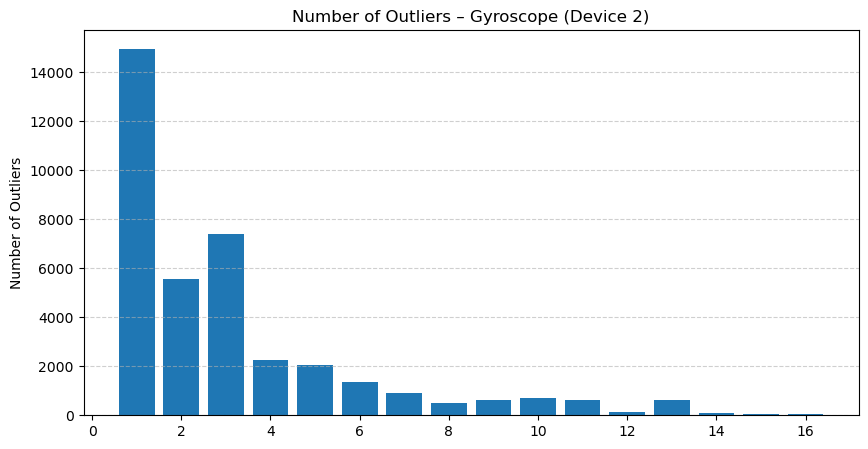


=== Magnetometer – Device 2 ===

Atividade 1: densidade = 0.00% (0/157882 pontos)
Atividade 2: densidade = 6.67% (5603/83968 pontos)
Atividade 3: densidade = 4.77% (3868/81152 pontos)
Atividade 4: densidade = 1.45% (2030/139934 pontos)
Atividade 5: densidade = 1.34% (1906/142366 pontos)
Atividade 6: densidade = 0.39% (349/89359 pontos)
Atividade 7: densidade = 0.22% (97/43791 pontos)
Atividade 8: densidade = 3.49% (232/6656 pontos)
Atividade 9: densidade = 7.35% (414/5632 pontos)
Atividade 10: densidade = 0.84% (56/6656 pontos)
Atividade 11: densidade = 6.83% (367/5376 pontos)
Atividade 12: densidade = 0.03% (1/3810 pontos)
Atividade 13: densidade = 0.00% (0/7620 pontos)
Atividade 14: densidade = 6.67% (254/3810 pontos)
Atividade 15: densidade = 6.67% (127/1905 pontos)
Atividade 16: densidade = 1.57% (30/1905 pontos)


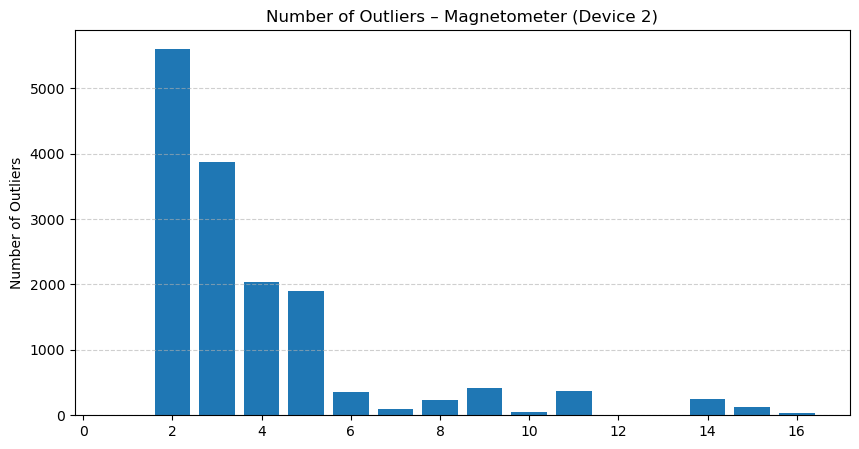

In [44]:
outliers_density(data, 1)  # Aceleration
outliers_density(data, 2)  # Gyroscope  
outliers_density(data, 3)  # Magnetometer

## Observações:
### Geral:
- A densidade de outliers varia significativamente entre os diferentes tipos de sensores e entre as diversas atividades, demonstrando que cada sensor capta diferentes aspetos do movimento do pulso direito.
- No dia a dia, esperariamos que atividades que envolvem movimentos como subir escadas, caminhas e por vezes até mesmo falar gerassem mais outliers. Mas será que os movimentos menos previssíveis, e não necessariamente os mais amplos, são os que geram mais valores atípicos?
- A análise dos gráficos requer algum cuidado na interpretação, pois as alturas das barras podem induzir em erro. Por exemplo, uma barra visualmente pode parecer que contém uma densidade maior de outliers, mas quando analisada a percentagem real, verifica-se que outra atividade tem na verdade maior densidade de outliers.
 
### Aceleração:
- As baixas densidades de outliers durante atividades estáticas e de deslocamento contínuo justificam-se pela natureza regular e previsível destes movimentos, que geram padrões de aceleração consistentes.
- Na atividades 8 a 11 e 14 observa-se uma densidade muito elevada de outliers. Estas atividades podem envolver mudanças bruscas com rápidas alterações de direção e intensidade do movimento que geram valores atípicos no sinal 
- nas atividades 15 e 16, apesar de serem também atividades de transição ( o que achamos que vai afetar muito), os valores são menos elevados. Isto pode dever-se ao facto destas transições ocorrerem entre atividades já dinâmicas, onde o corpo ja está habituado ao movimento e as transições são portanto mais suaves e menos bruscas.
#### Conclusão:
- este sensor é particularmente sensível a transições e atividades que envolvem mudanças de aceleração.

### Giroscópio:
- A densidade de outliers no giroscópio apresenta um padrão distinto, com a atividade 9 a mostrar uma redução face ao outro sensor, mas mantendo-se elevada. A variação entre sensores deve-se à diferente natureza física que cada um mede, uma vez que nesta atividade não rodamos muita vez o pulso.
- a maioria das atividades apresenta densidades mais elevadas neste sensor relativamente ao acelerómetro provavelmente causado pela maior sensibilidade do giroscópio a movimentos do corpo e a ajustes posturais.
- as atividades 1, 3, 9, 10 e 11 são as que apresentam percentagens mais elevadas. Isto justifica-se pelo facto de envolverem movimentos já estabilizados, onde o pulso mantém uma postura relativamente regular.
- Curiosamente, as atividades que à partida esperariamos que mais influenciassem o giroscópio seriam as 16, 7 e 14 na nossa perspetiva. No entanto, ao analisarmos percebemos que não apresentam as densidades mais elevadas. Isto justifica-se pelo facto destas atividades envolverem já uma estabilidade.
#### Conclusão:
- o giroscópio, sendo mais sensível ao movimento de rotação do pulso, regista uma maior densidade de outliers em situações que envolvem manter o corpo estável. 

### Magnetómetro:
- As atividades que esperaríamos que mais influenciassem o magnetómetro (14, 15 e 16) não apresentam as densidades mais elevadas.
- atividades como a 1, 6, 7, 10, 12, 13 têm densidades nulas ou muito baixas, possivelmente por repetirem gestos muitos previsíveis que não alteram significativamente a orientação do sensor.
- Este é o sensor com as menores densidades de outliers, indicando que é menos afetado por variações de movimento. 
- atividade com maior valor é a 9, possivelmente devido a mudanças inesperadas de orientação do pulso durante a transição de estar sentado.
- atividade 2 e 3 aumentaram consideravelmente em relação aos outros sensores, o que pode dever-se a ajustes de posição por desconforto durante períodos prolongados sentado 
#### Conclusão:
- O magnetómetro apresenta um padrão de outliers menos relacionado com a dinâmica do movimento e mais com variações contextuais.

### Exercício 3.3
Escreva uma rotina que receba um Array de amostras de uma variável e identifique os outliers usando o teste Z-Score para um k variável (parâmetro de entrada).

In [ ]:
from scipy import stats
# zscore = (valor - média) / desvio_padrão
def detect_outliers_zscore (samples, k):
    z_scores = stats.zscore(samples, nan_policy='omit')
    return np.abs(z_scores) > k


[False False False ... False False False]


#### Explicação da rotina:
- Inicialmente implementamos uma versão manual para este exercício através do cálculo: z_scores = np.abs((samples - mean) / std), onde qualquer valor com z_score absoluto superior ao limiar k era considerado outlier. No entanto, após pesquisarmos alternativas mais robustas, optámos pela versão utilizando a biblioteca SciPy. Esta decisão deveu-se a várias vantagens:
1. robustez e segurança.
2. configuramos o parâmetro nan_policy=omit para lidar adequadamente com valores não numéricos. Esta escolha é importante porque trabalhamos com dados de sensores, Ao utilizar omit, garantimos que qualquer valor não válido é excluído do cálculo do z-score.

- Escolhemos especificamente a opção omit em alternativa a propagate ou raise, pois desta maneira mantemos a execução do código mesmo na presença de dados incompletos, ao mesmo tempo que asseguramos que os cálculos são baseados apenas em valores válidos. 
- No final vai retornar um array boolenao onde True indica que é outlier

### Exercício 3.4
Usando o Z-score implementado, assinale todos as amostras consideradas outliers nos módulos dos vetores de aceleração, giroscópio e magnetómetro.
Apresente plots em que estes pontos surgem a vermelho, enquanto os restantes surgem a azul. Use k=3, 3.5 e 4.

In [ ]:
def plot_zscore_outliers(data, sensor, k_values=[3.0, 3.5, 4.0]):
    if sensor == 1:  
        c = (2, 3, 4)
        label = 'Acceleration'
    elif sensor == 2: 
        c = (5, 6, 7)
        label = 'Gyroscope'
    elif sensor == 3:  
        c = (8, 9, 10)
        label = 'Magnetometer'
    else:
        raise ValueError("sensor must be 1, 2 ou 3")

    # módulo = sqrt(x² + y² + z²)
    mod = np.sqrt((data[:, c] ** 2).sum(axis=1))

    #informações 
    activities = data[:, 12].astype(int)
    devices = data[:, 1].astype(int)
    unique_activities = np.unique(activities)
    unique_devices = np.unique(devices)

    # Loop para cada valor de k
    for k in k_values:
        # Loop por cada dispositivo
        for dev in unique_devices:
            #cria figura para cada dispositivo e para cada k
            plt.figure(figsize=(10, 5))
            plt.title(f'{label} - Device {dev} | Outliers Z-Score (k={k})')
            
            
            for i, act in enumerate(unique_activities):
                mask = (devices == dev) & (activities == act)
                mod_act = mod[mask]
                
                if len(mod_act) == 0:
                    continue  # pular se não há dados
                
                out = detect_outliers_zscore(mod_act, k)
                
                # Pontos normais em azul
                normais = mod_act[~out]
                plt.scatter([i+1]*len(normais), normais, color='blue', s=20)
                # Outliers em vermelho
                outliers = mod_act[out]
                plt.scatter([i+1]*len(outliers), outliers, color='red', s=40)
            
            plt.xlabel('Activity')
            plt.ylabel(f'{label} Module')
            plt.xticks(range(1, len(unique_activities)+1), [f"A{a}" for a in unique_activities], rotation=90)
            plt.tight_layout()
            plt.show()


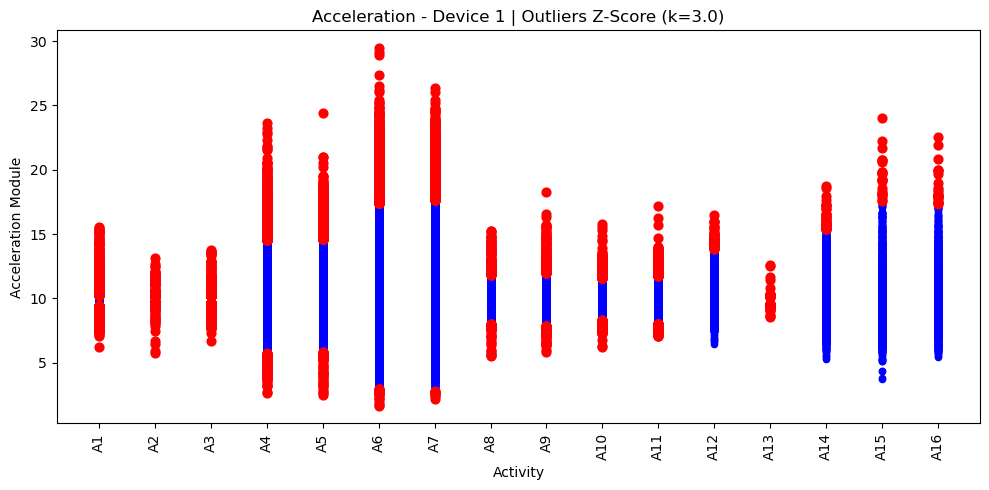

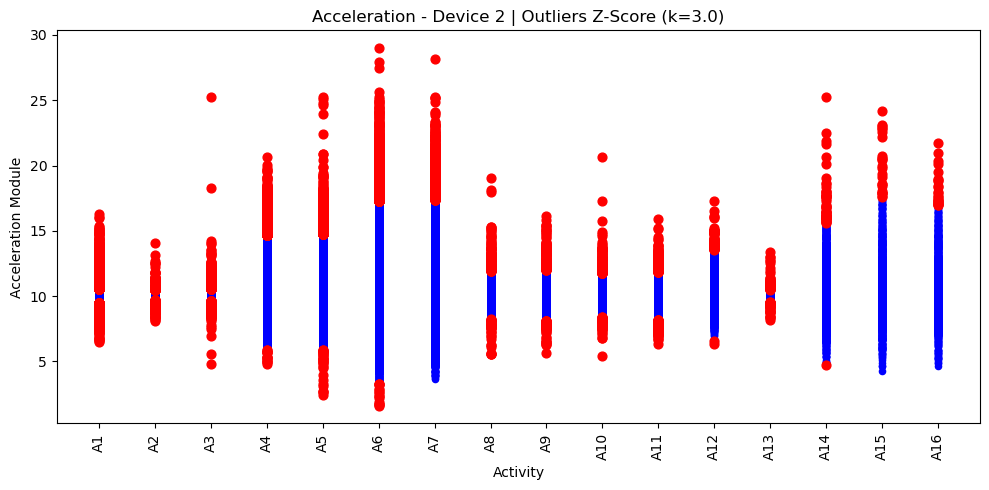

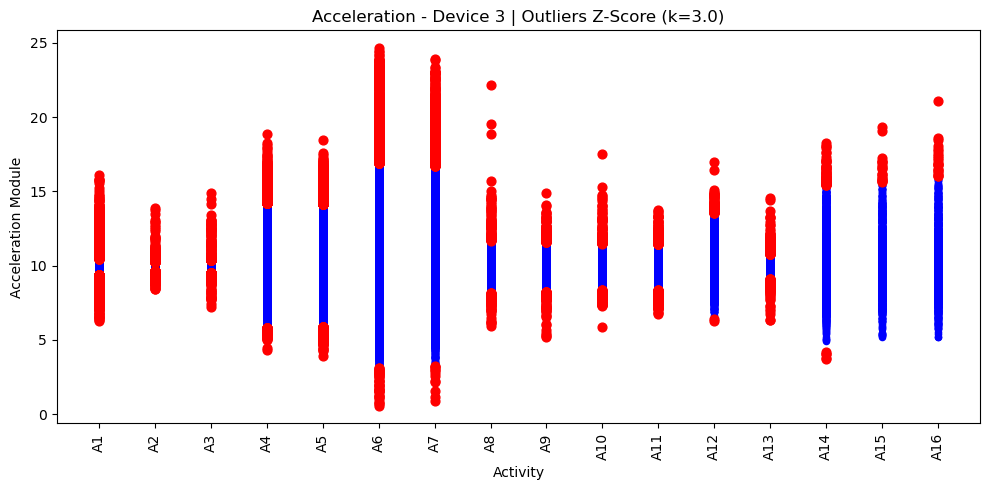

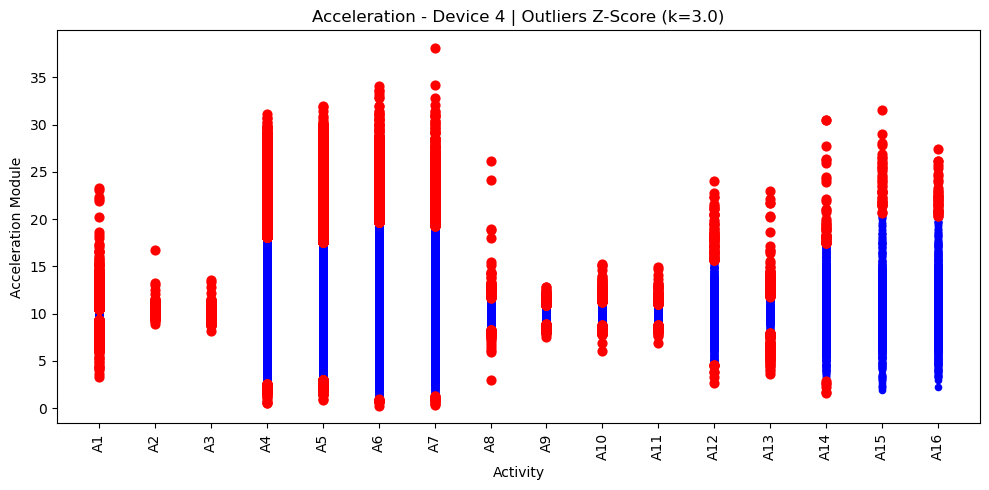

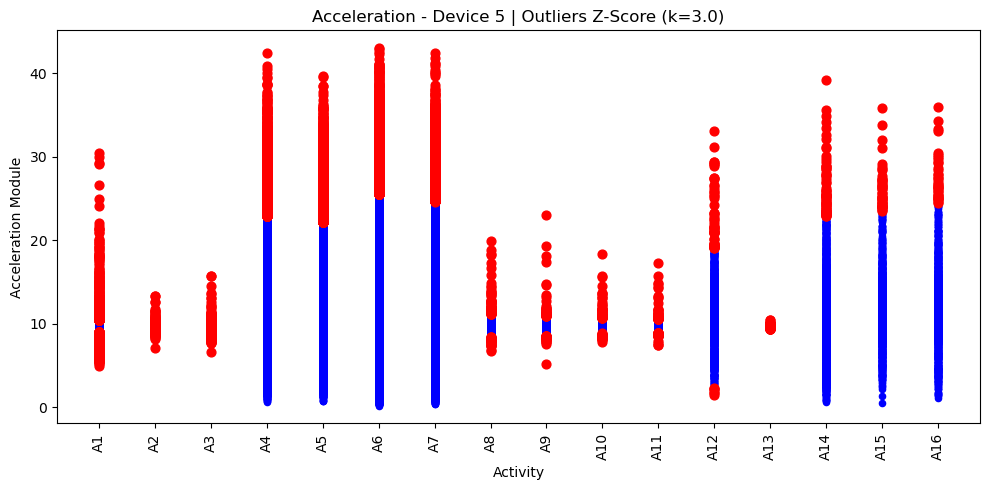

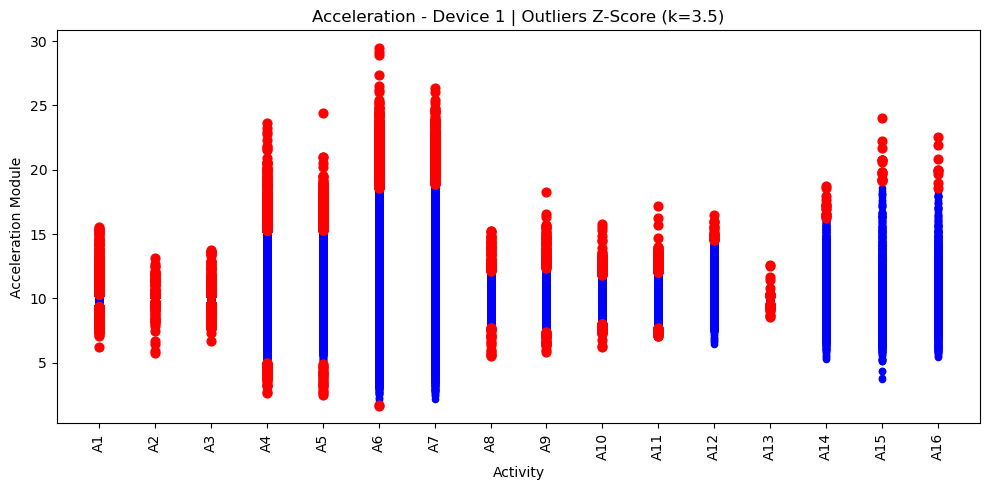

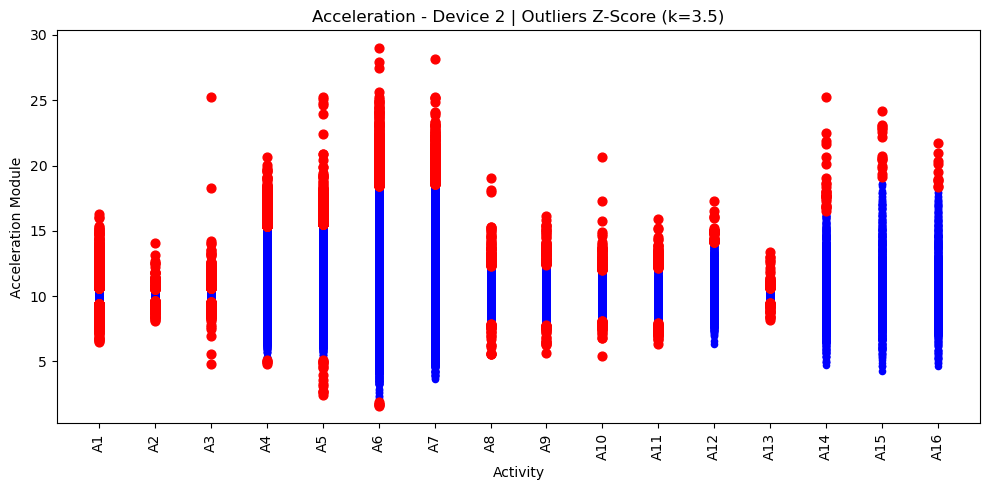

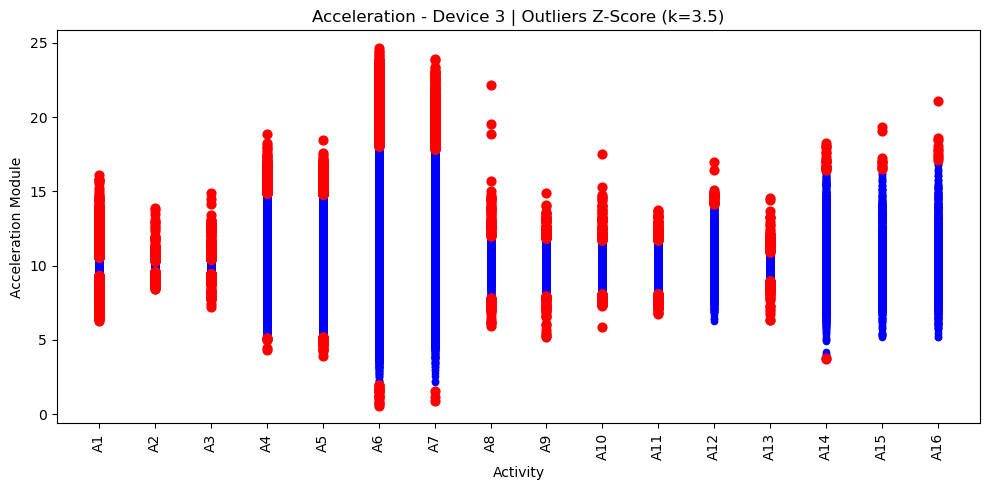

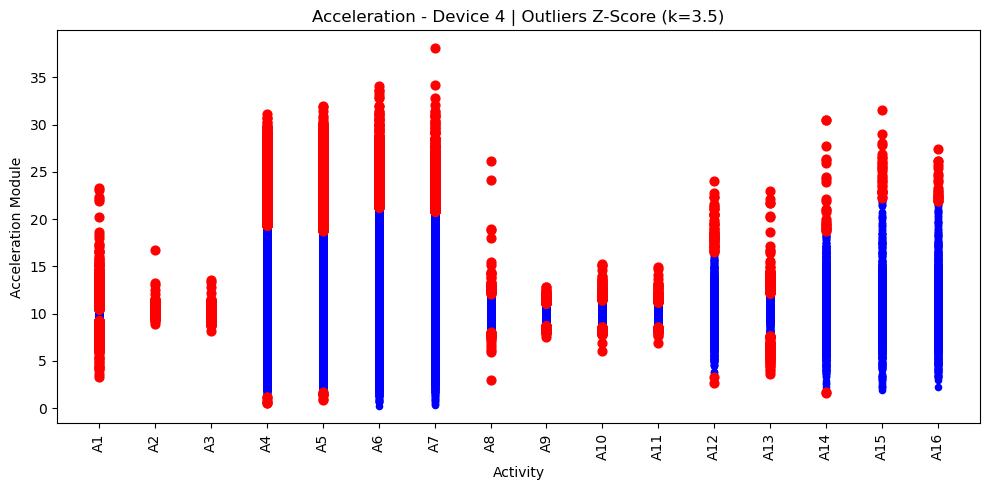

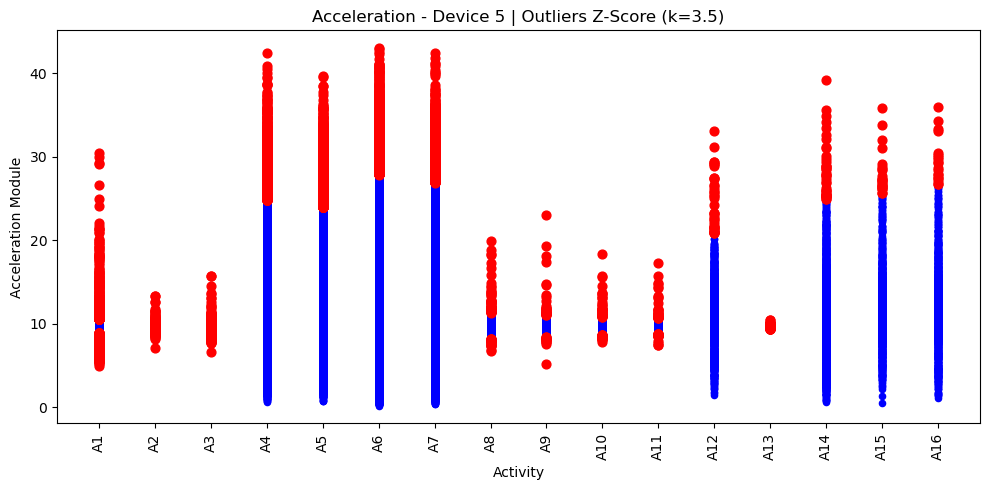

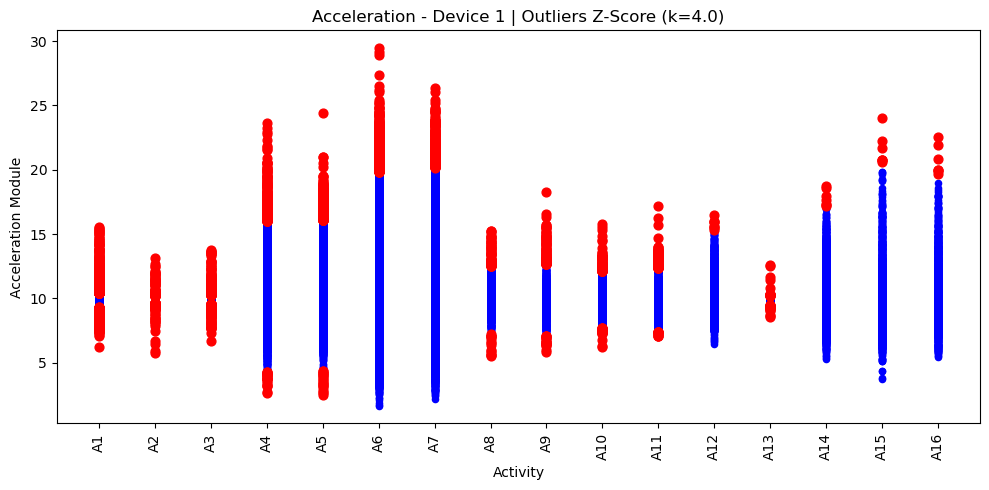

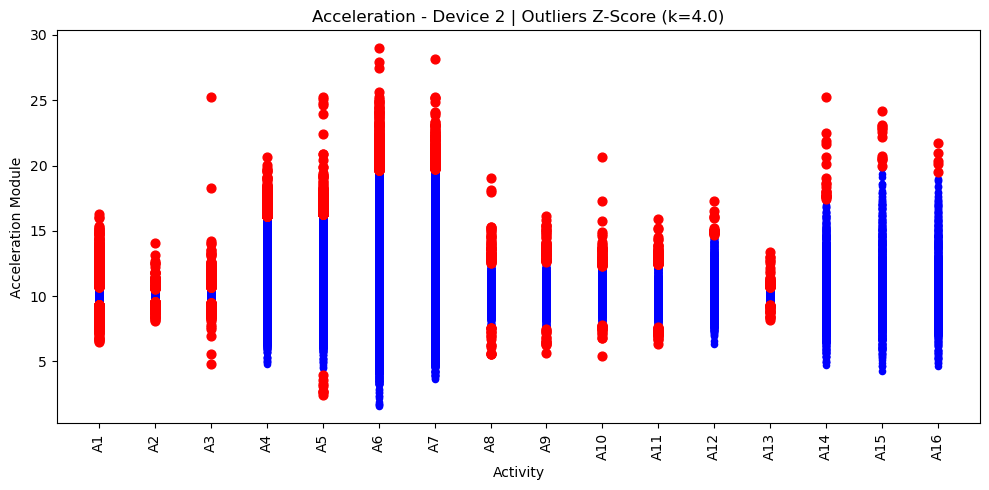

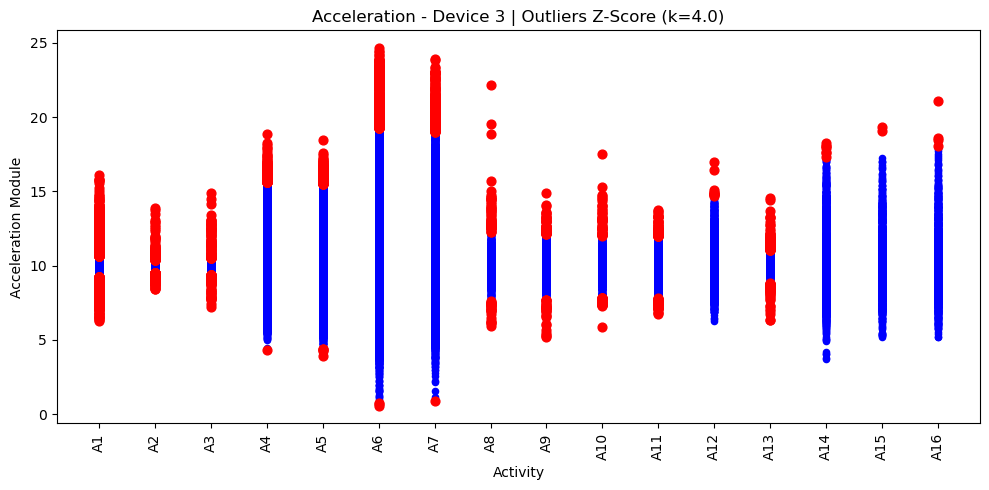

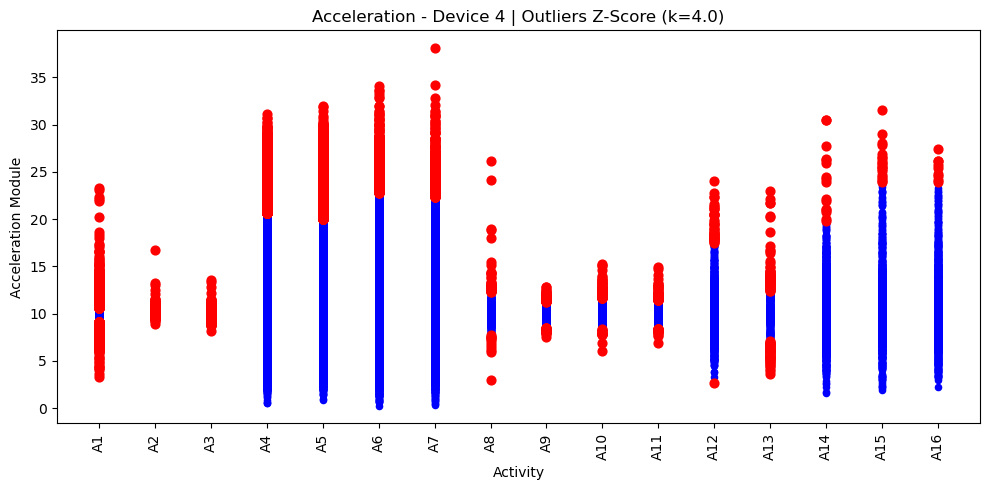

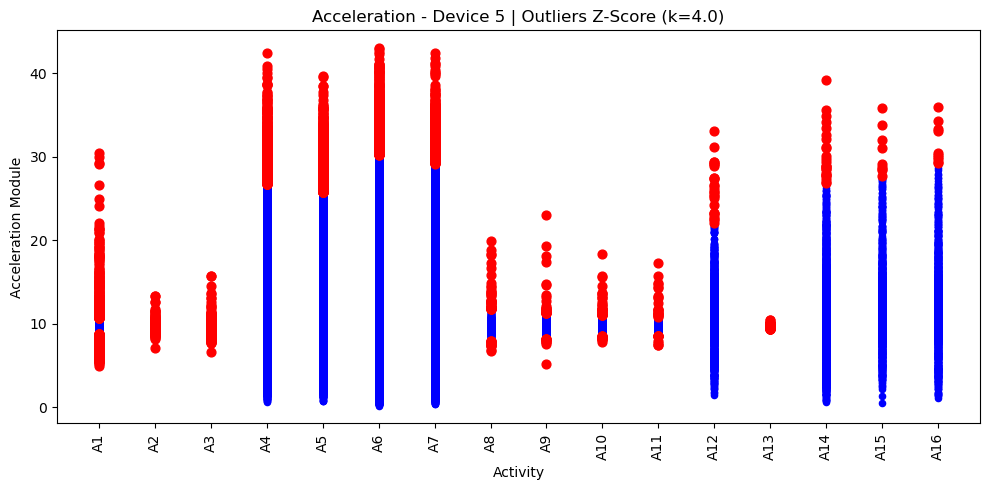

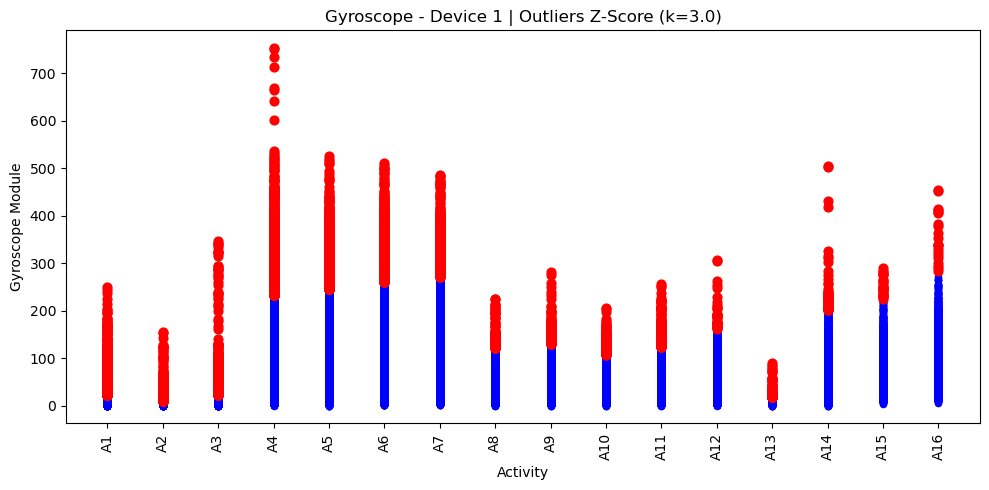

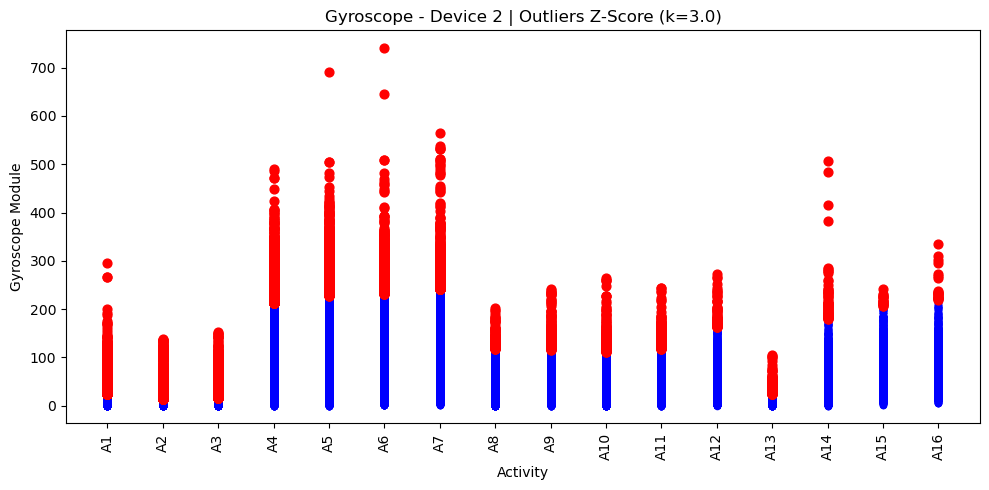

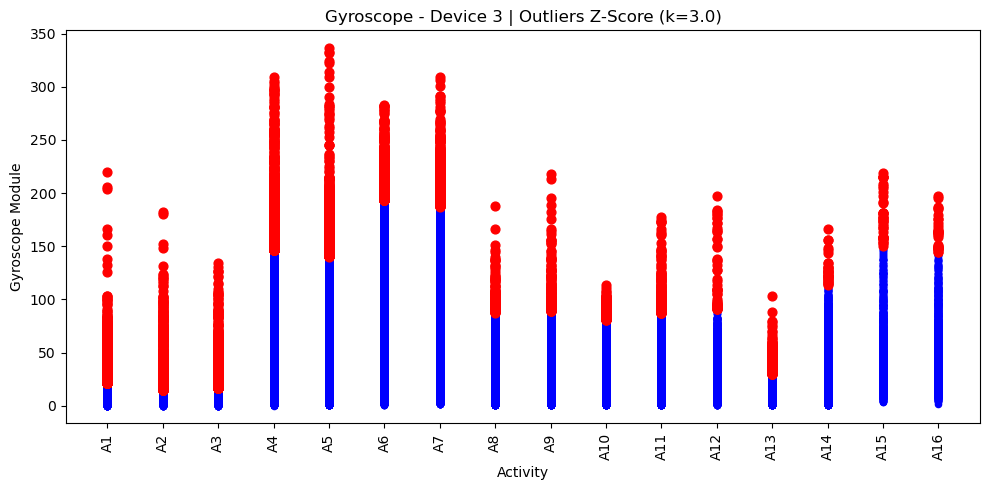

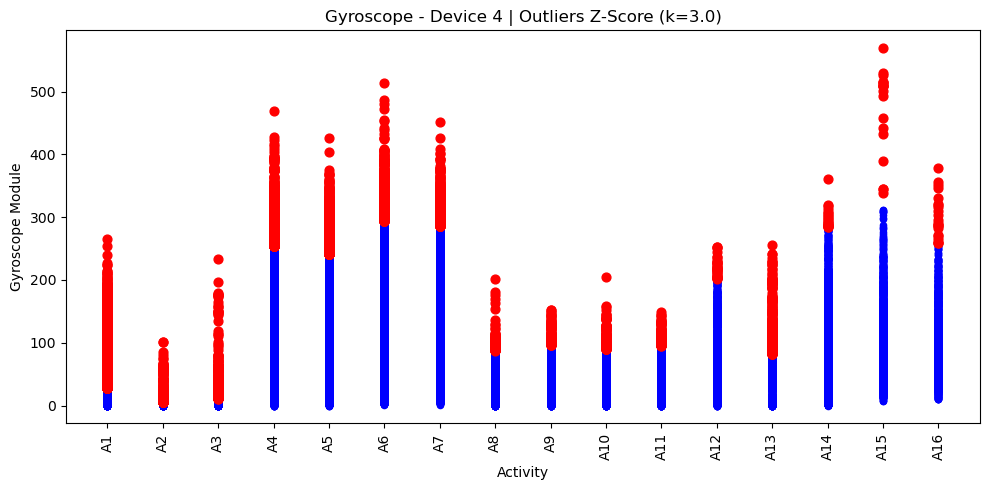

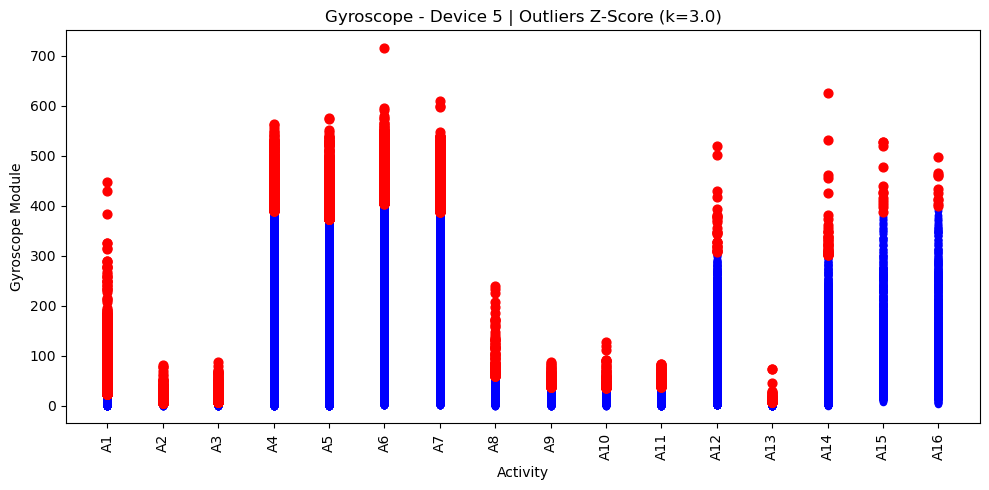

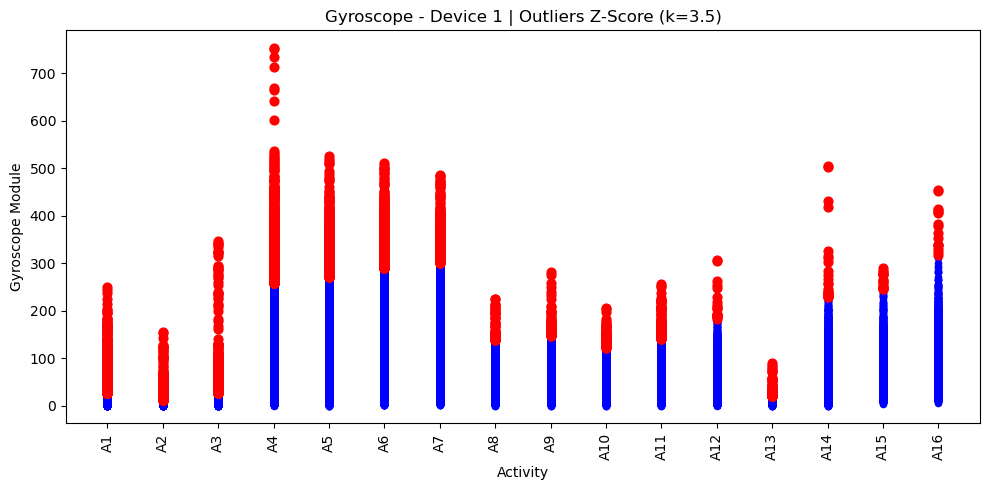

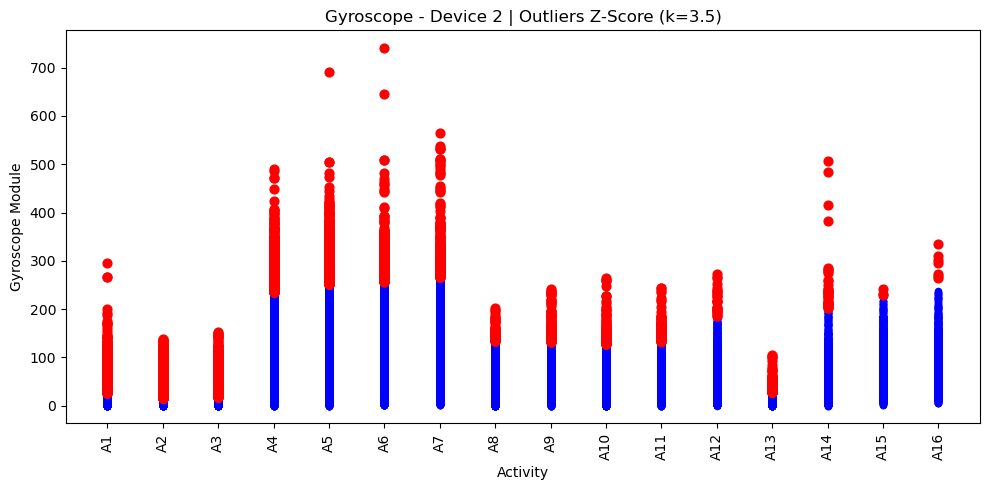

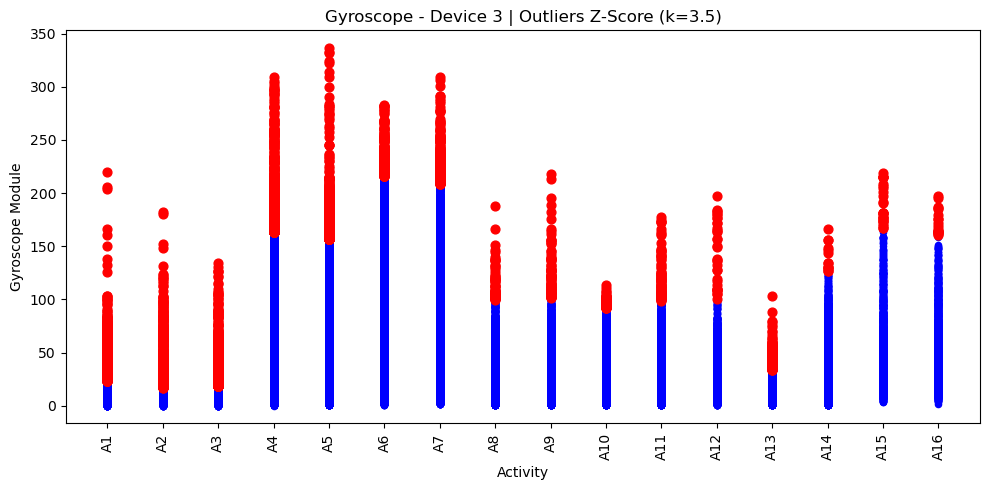

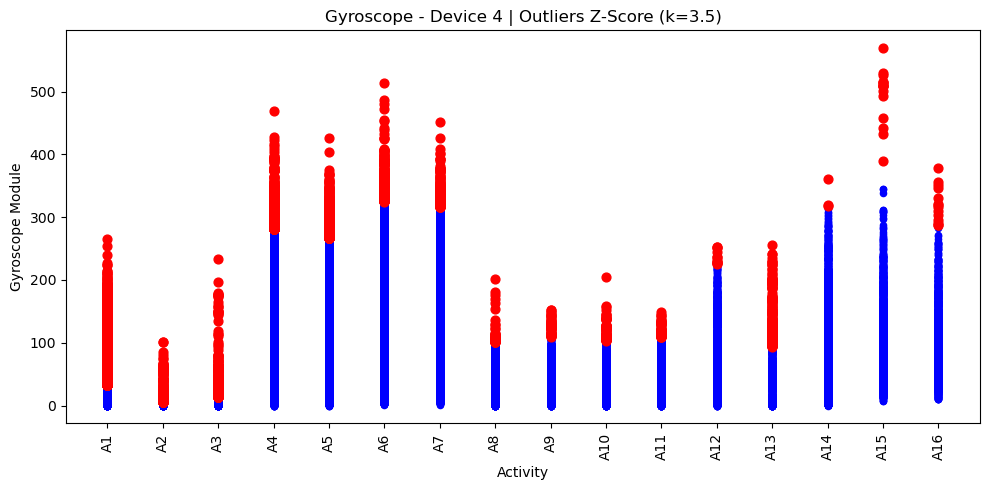

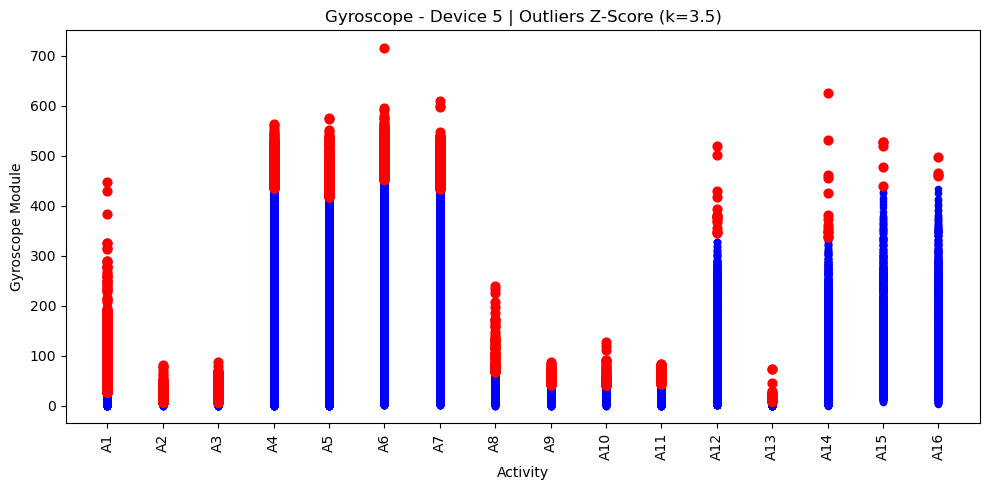

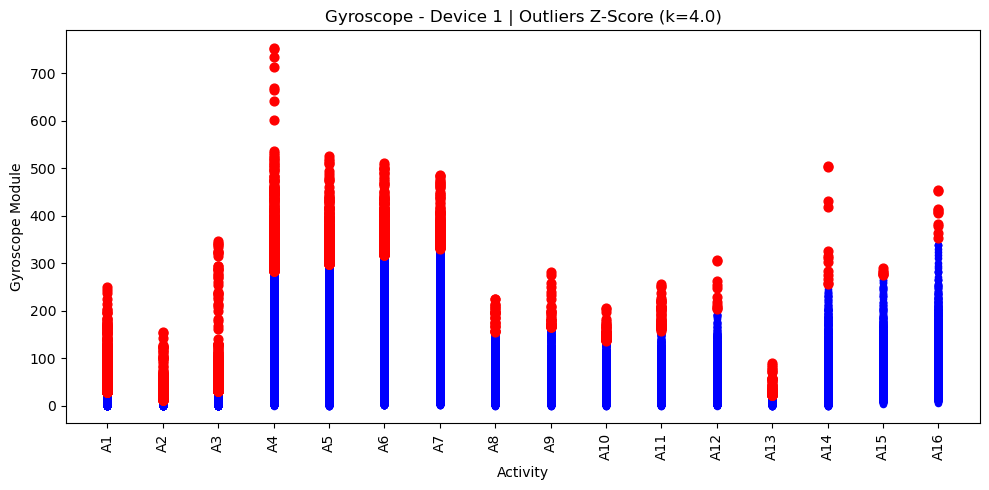

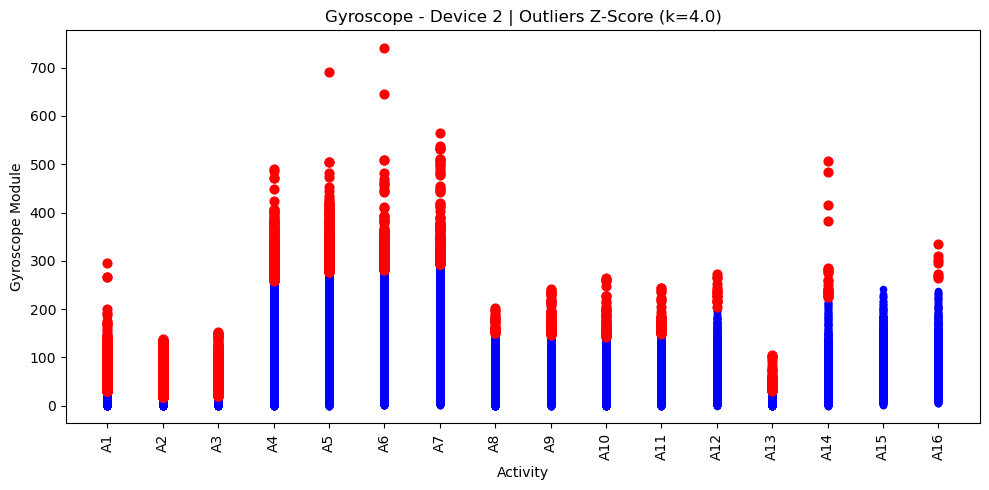

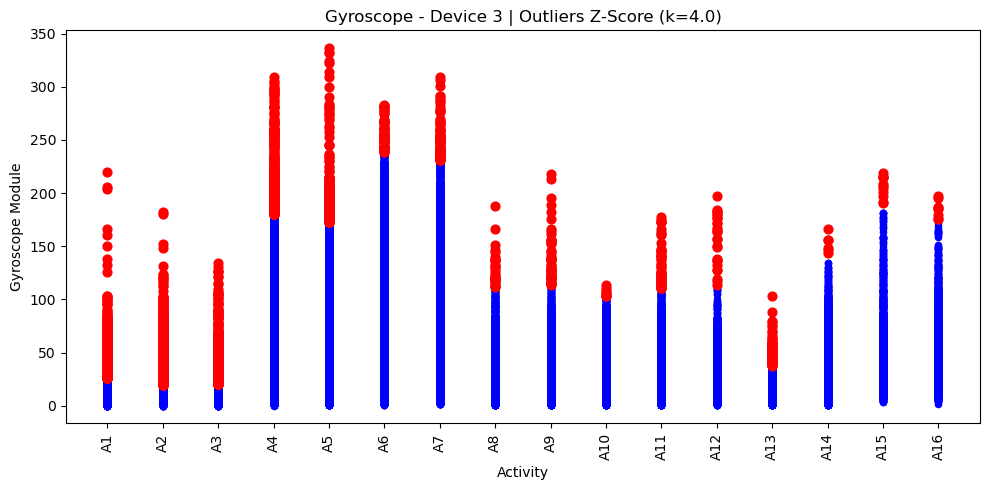

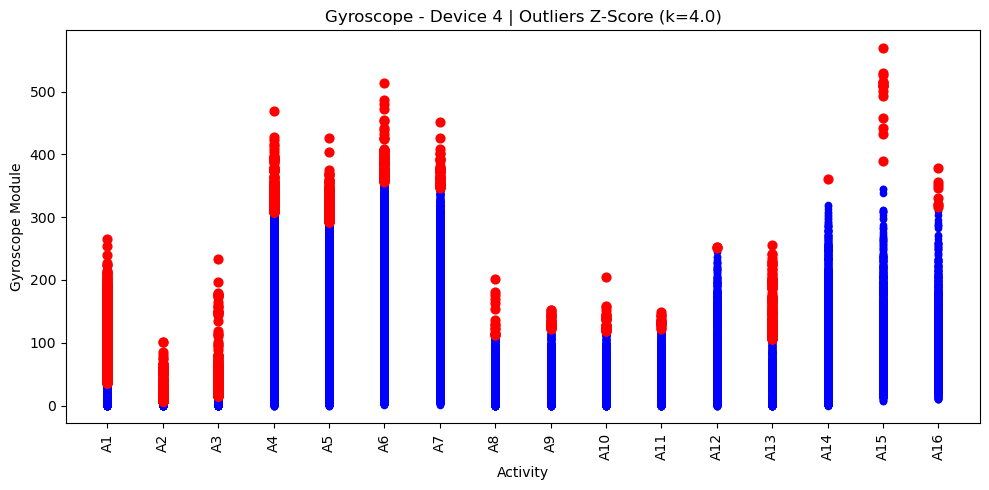

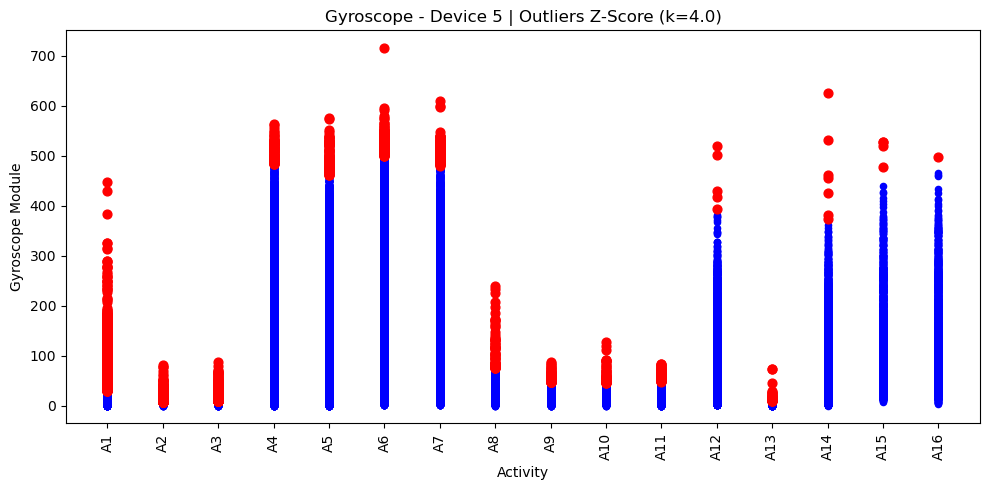

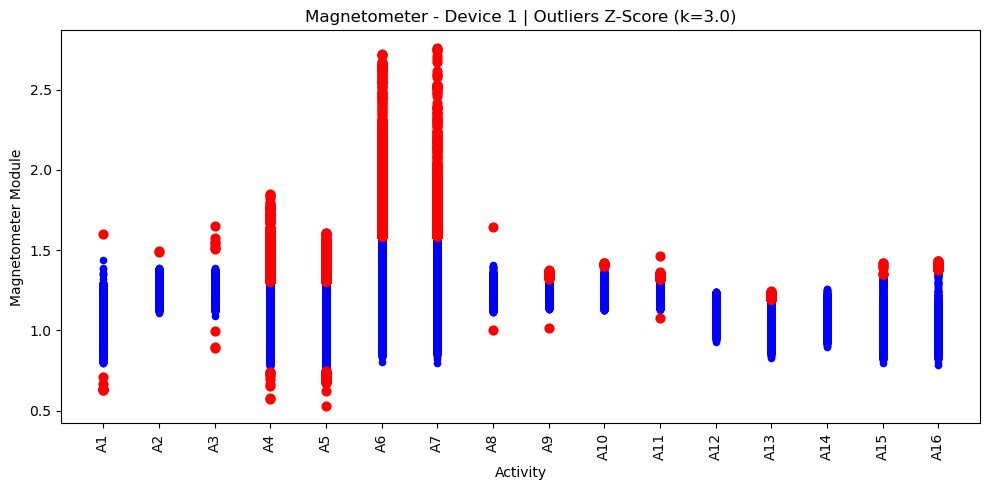

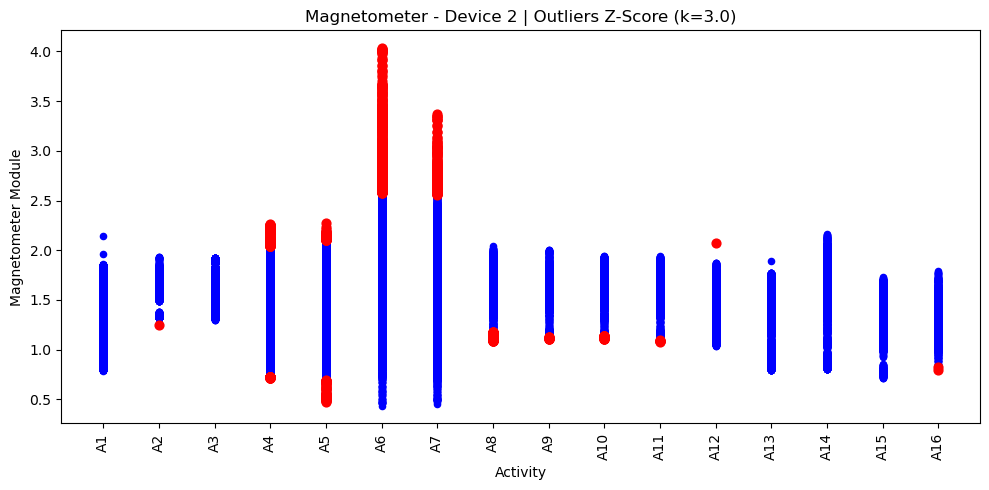

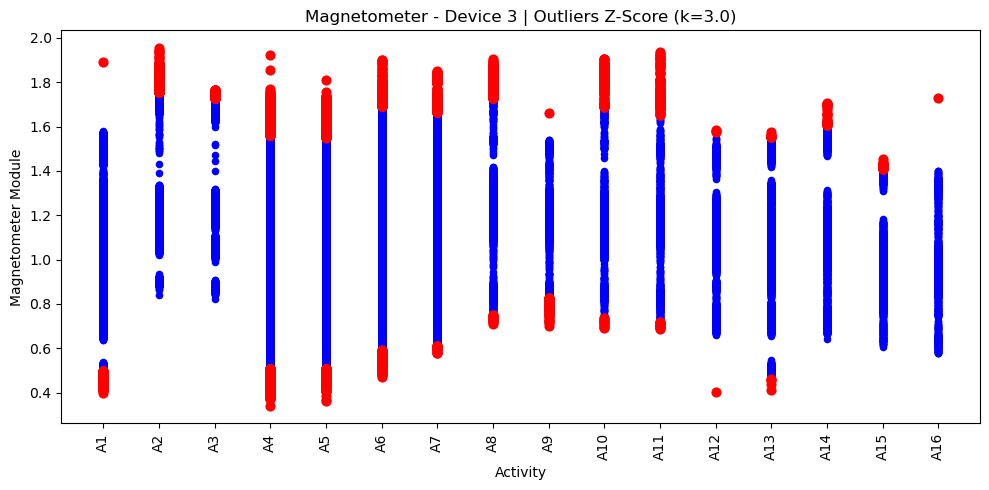

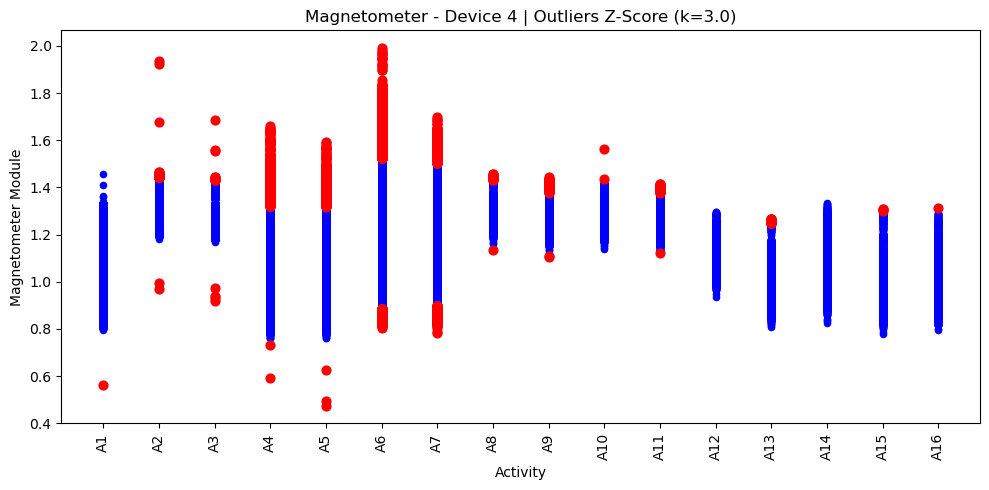

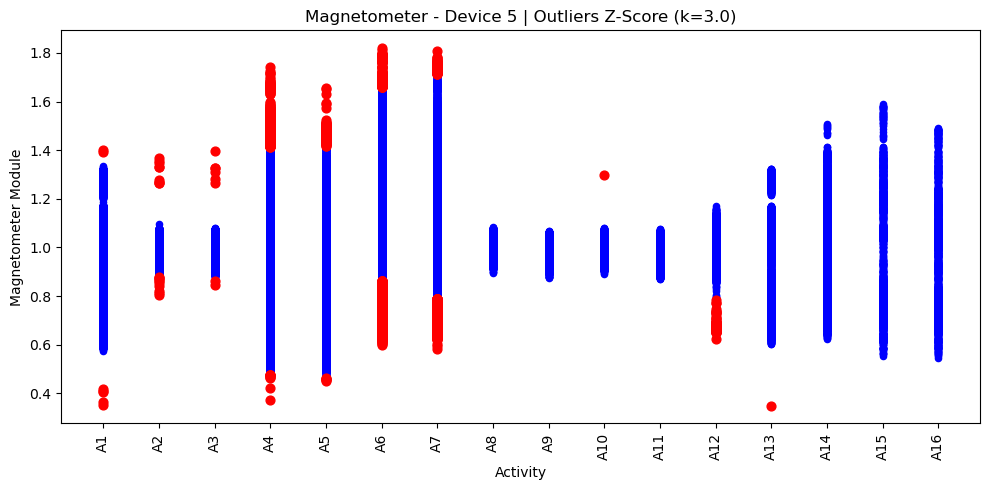

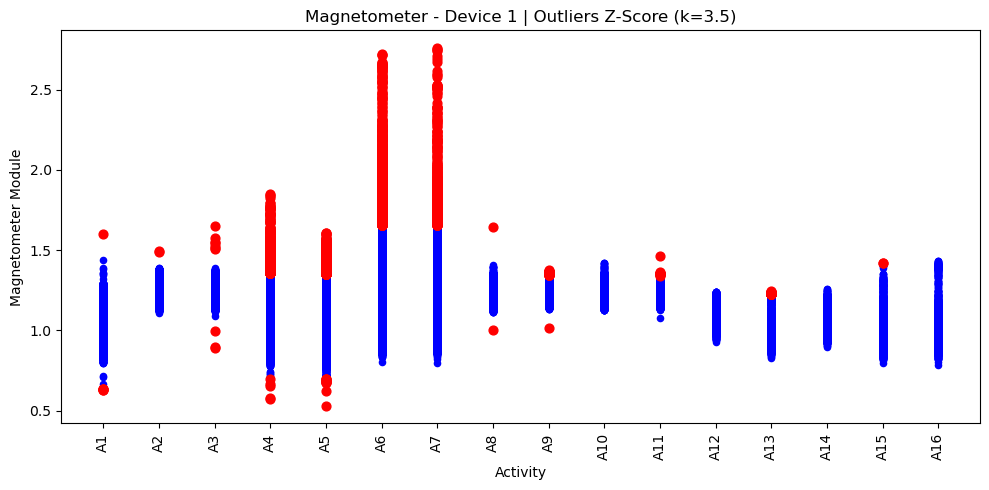

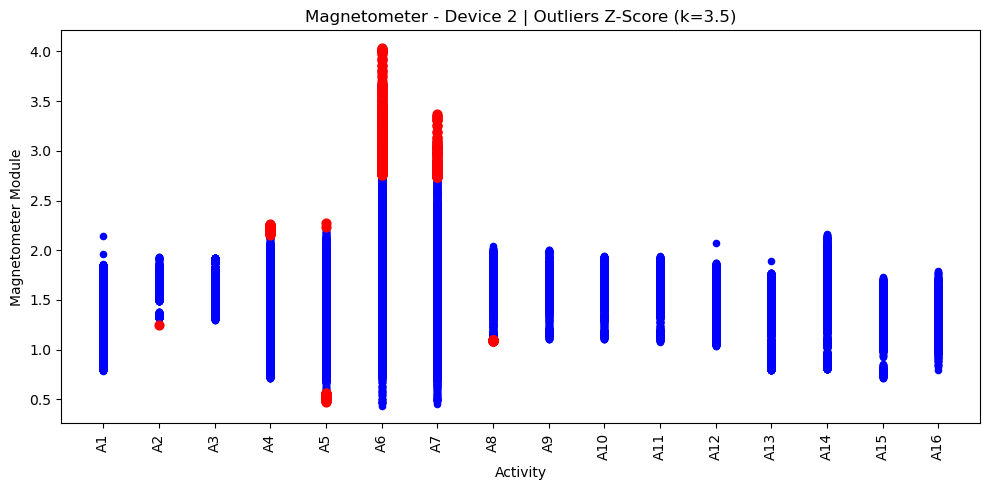

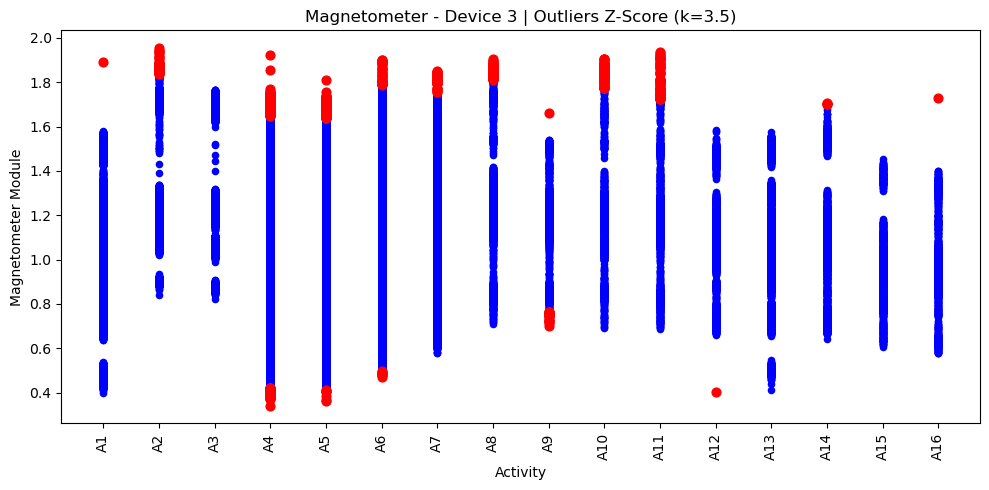

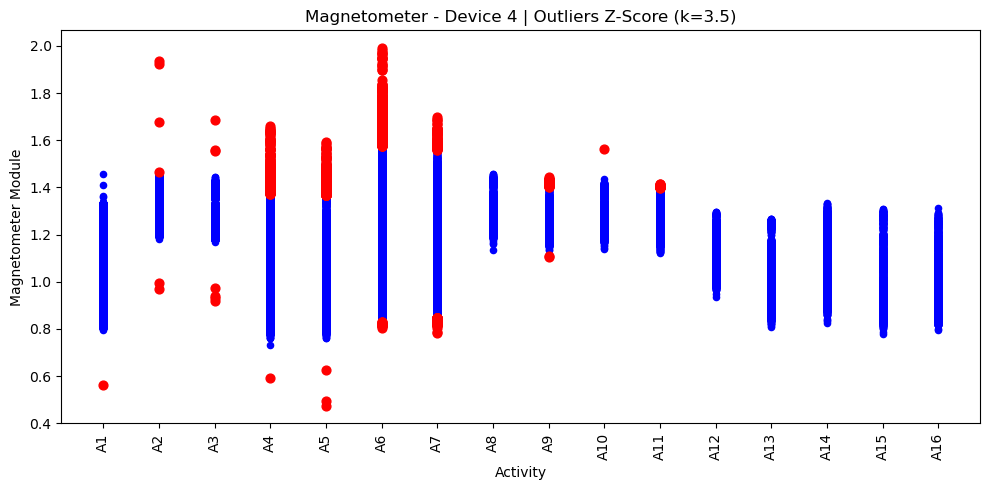

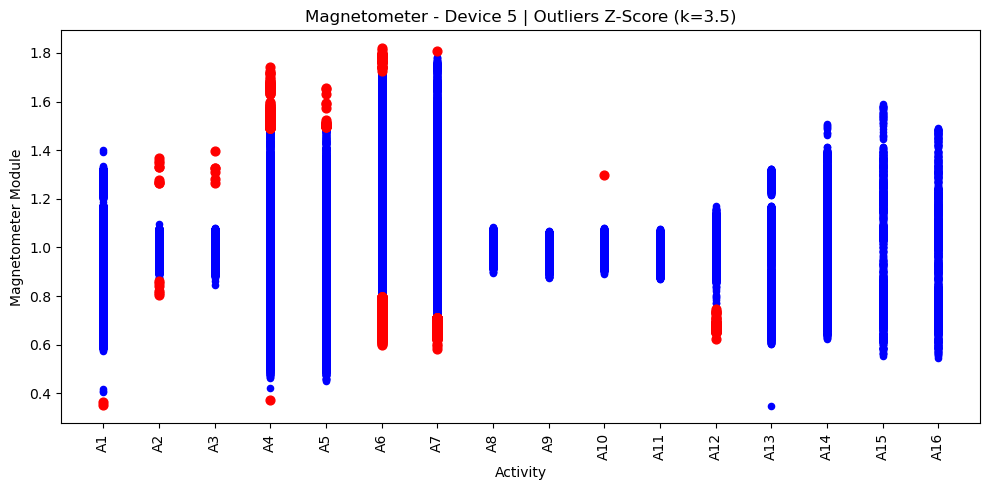

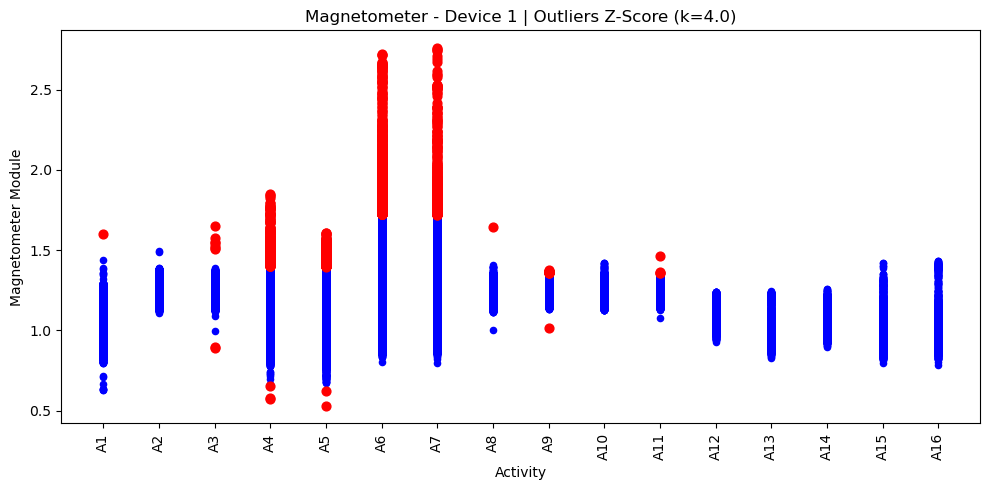

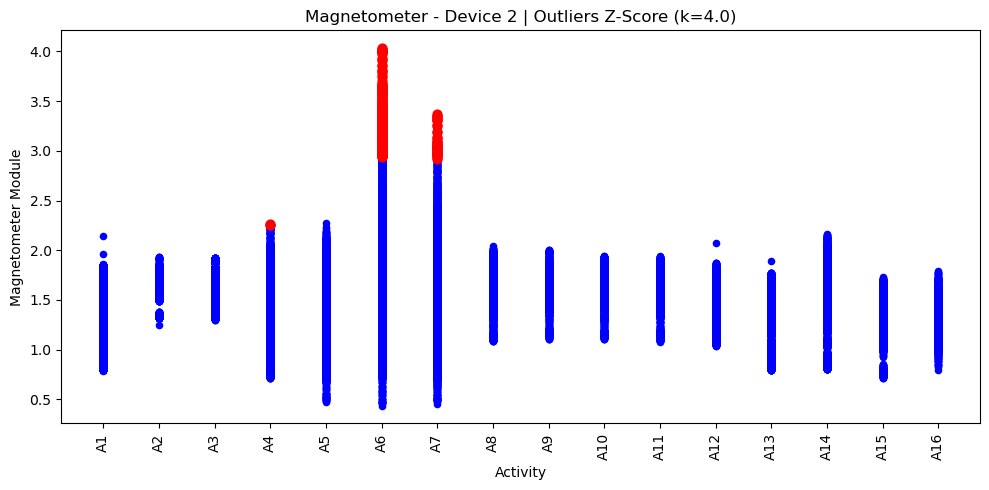

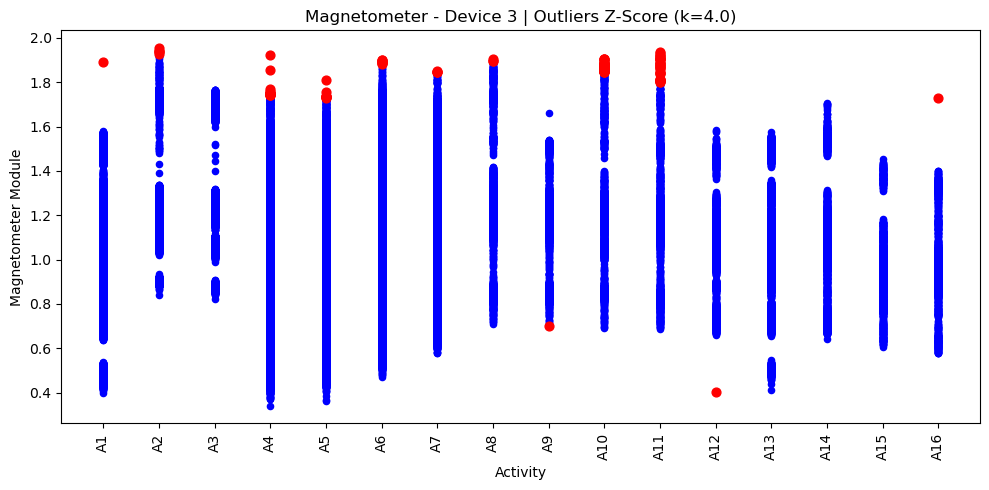

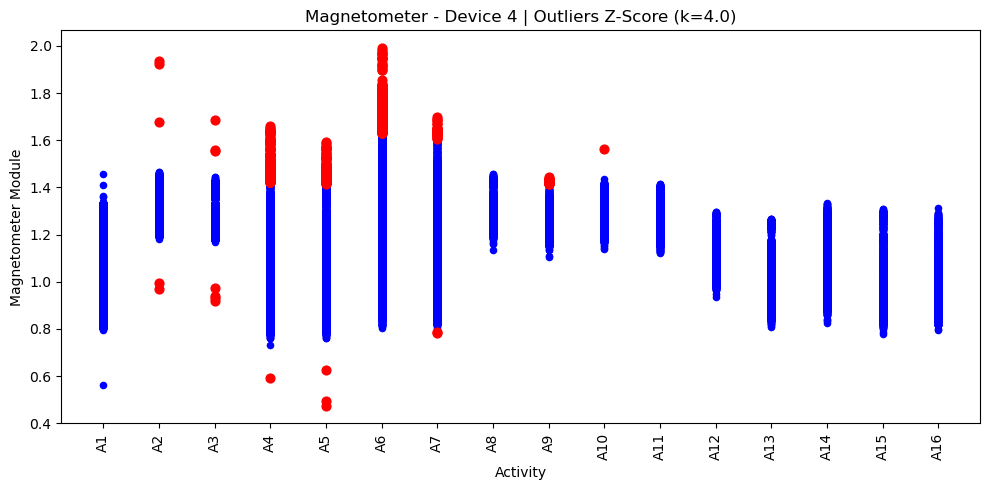

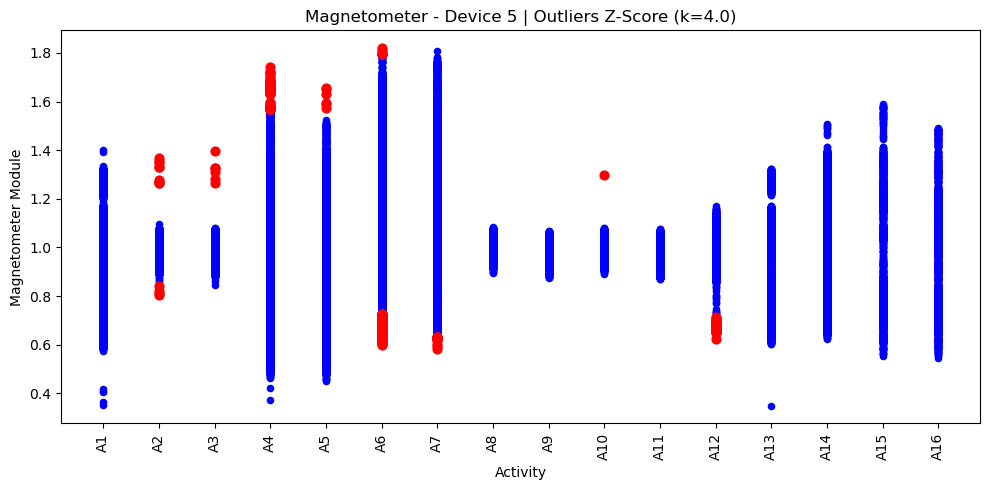

In [32]:
plot_zscore_outliers(data, sensor=1)  # Aceleração
plot_zscore_outliers(data, sensor=2)  # Giroscópio
plot_zscore_outliers(data, sensor=3)  # Magnetômetro

### Observações
#### Análise dos Gráficos Z-Score
Os gráficos 2D do Z-Score mostram os outliers (a vermelho) identificados em cada atividade, com base no módulo de cada sensor (aceleração, giroscópio e magnetómetro)
##### Observação do k:
Como se pode observar nos gráficos, o valor de k funciona como um limiar de tolerância.
- Com k = 3.0 (tolerância baixa), o método é muito rigoroso e marca uma grande quantidade de pontos como outliers, especialmente em atividades dinâmicas.
- Com k = 3.5 (tolerância média), o número de outliers detetados diminui, mas ainda é considerável, refletindo a variabilidade natural dos movimentos humanos.
- Com k = 4.0 (tolerância alta), o número de outliers detetados diminui significativamente, pois o limiar para considerar um ponto anómalo é mais elevado.
##### Limitações do Z-Score:
O Z-Score baseia-se na média e no desvio-padrão de toda a atividade. Em movimentos humanos, que têm naturalmente uma alta variabilidade, muitos pontos que são picos normais do movimento acabam por ser marcados como outliers. Ele apenas vê a magnitude sem considerar o contexto.

### Aceleração:
  - DISPOSITIVO 1: Com o aumento do limiar k de 3.0 para 3.5, observa-se uma redução de outliers. As atividades 4, 5 e 6 apresentam as maiores reduções, o que indica que estas captam movimentos naturais do pulso durante mudanças de posição e deslocamento que podem ser erradamente classificados como anomalias com limiares mais restritivos. A atividade 1 manteve muitos outliers mesmo com k=3.5, sugerindo a presença de movimentos atípicos durante períodos de repouso. Quando o k aumenta para 4.0, observa-se uma redução ainda mais acentuada nos outliers totais, com as atividades 4, 5, 6 mostrando as quedas mais pronunciadas. Ainda assim, a atividade 1 mantém uma proporção relativamente maior de outliers, reforçando a hipótese de comportamentos atípicos. A localização do sensor no pulso esquerdo mostrou-se particularmente sensível à variabilidade natural e movimento.
  - DISPOSITIVO 2: comportamento semelhante ao pulso esquerdo. Ambos os pulsos exibem reduções acentuadas nas atividades dinâmicas com o aumento do k, mas o pulso direito mostra um maior número de outliers na atividade 1 e quedas mais visíveis nas atividades 4 a 6.
  - DISPOSITIVO 3: o que se destaca mais é a atividade 13. Com um k mais baixo, existe um maior numero de outliers devido a constantes variações de movimento e equilíbrio registadas no peito. As atividades 4 e 6 também revelam muitos outliers, refletindo a alta variabilidade de aceleração no peito durante estes movimentos. 
  - DISPOSITIVO 4: verfica-se uma redução progressiva de outliers com o aumento de k, especialmente nas atividades dinâmicas como a 4 e 6. Contudo, mesmo com um limiar mais restritivo, as atividades estáticas como a 1 ou 2 mantêm quantidades relativamente elevadas de outliers, possivelmente devido à localização do sensor na perna, parte que está sujeita a movimentos naturais e ajustes posturais mesmo durante o repouso.
  - DISPOSITIVO 5: Em todos os valores de k, as atividades 4 e a 5 são consistentemente as que apresentam mais outliers o que é justificável, pois o sensor na perna está diretamente envolvido no movimento, gerando sinais de aceleração mais variáveis.
  #### Conclusão:
  - Independente do limiar, observa-se uma concentração significativa de outliers nas atividades 4, 5, 6 e 7. Isso sugere que movimentos dinâmicos e combinados com fala geram maior variabilidade nos sinais de aceleração.
  
### Giroscópio :
  - DISPOSITIVO 1 e 2: a atividade com mais outliers é a 1, possivelmente porque qualquer movimento mínimo ou involuntário é considerado uma variação extrema.
  - DISPOSITIVO 2: na atividade 14 não existe outliers em k=4 isto pode ser ao facto de **continuar**
  - DISPOSITIVO 3: as atividades como 4 e 5 em relação aos outros dispositivos é o que tem o maior número de outliers porque no peito é onde se consegue capturar todos os movimentos corporais da parte de cima enquanto outros sensores medem apenas movimentos mais restritivos
  - DISPOSITIVO 4: a atividade com mais outliers é a 1, o que é interessante uma vez que ficar em pé é considerada por não ter muitos movimentos. Isto pode ser explicado através dos ajustes que o corpo faz para manter o equilibrio. 
  - DISPOSITIVO 5: os maiores números de outliers ocorrem durante as atividades 1, 2, 4 e 6 que são atividades com forte movimento da perna. A localização do sensor na perna inferior esquerda parece influenciar estes resultados uma vez que atividades dinâmicas como a 4 ou a 7, onde o movimento da perna é mais previsível e contínuo, tendem a ter menos outliers em comparação com posturas estáticas.
  #### Conclusão:
  - O giroscópio mostra maior sensibilidade a pequenos movimentos e a ajustes de corpo especialmente em atividades estáticas. Já nas outras atividades os outliers tendem a ser menos.

### Magnetómetro:
  - DISPOSITIVO 1 e 2: valores de outliers mais baixos nestes dispositivos provavelmente devido à sua localização menos exposta ao campo magnético. No entanto as atividades 4 a 7 ainda exibem valores mais altos, indicando que o movimento do braço pode interferir variações no campo magnético.
  - DISPOSITIVO 3: a atividade 1 destaca-se, onde para k= 3.0 existem muitos outliers, mas para k=3.5 e 4.0 os outliers tornam-se quase nulos. As outras atividades não apresentam variações tão drástica.
  - DISPOSITIVO 4: a atividade 6 é a que mais se destaca. 
  - DISPOSITIVO 5: as atividades 2,3,4,5,6,7 e 12 apresentam outliers em todos os limiares de k porque envolvem os principais movimentos da perna. As restantes atividades não registam outliers por não existir um movimento significativo da perna e sem picos significativos.
  #### Conclusão:
  - É o sensor que tem menos outliers independente do valor de k. Isto ocorre porque as variações no campo magnético são geralmente mais estáveis e menos afetadas, tornando este sensor menos sensível à variabilidade dos movimentos humanos.

### Exercício 3.5
#### Compare e discuta os resultados obtidos em 3.1 e 3.4. 


=== BOXplots - Pulso Direito (Device 2) ===


C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


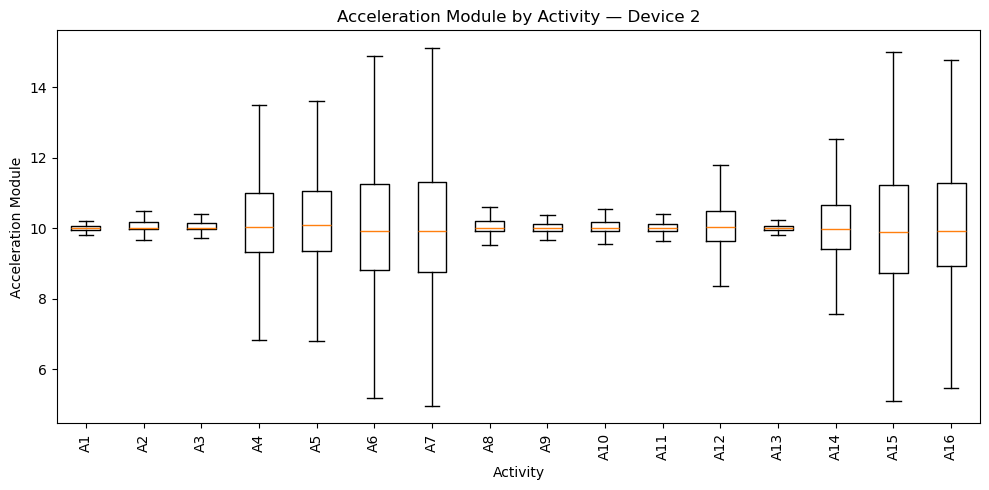

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


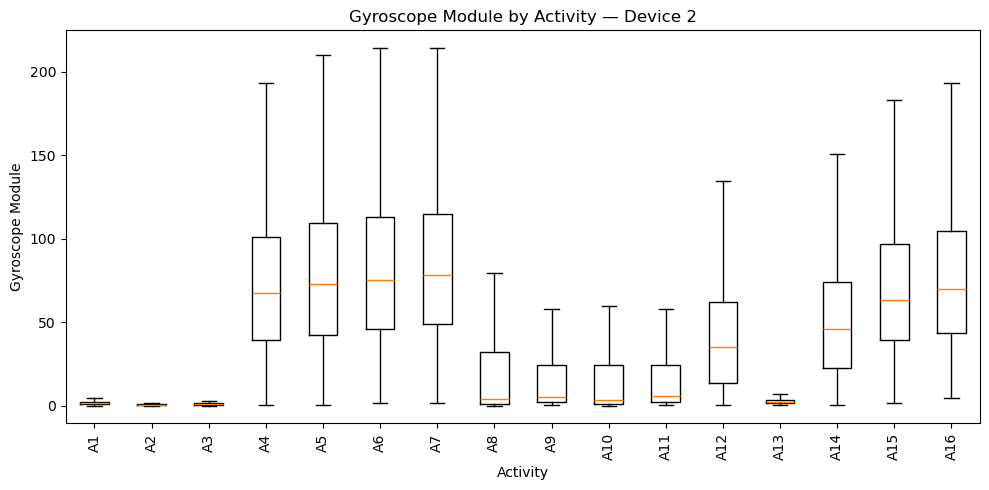

C:\Users\HP\AppData\Local\Temp\ipykernel_14392\1436966769.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=[f"A{a}" for a in unique_activities], showfliers=False)


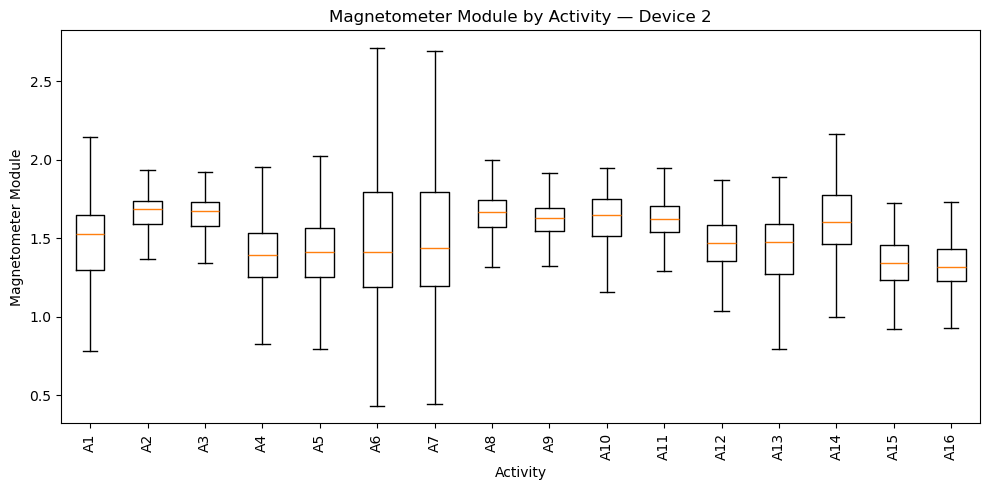

=== Outliers Z-Score - Pulso Direito (Device 2) ===


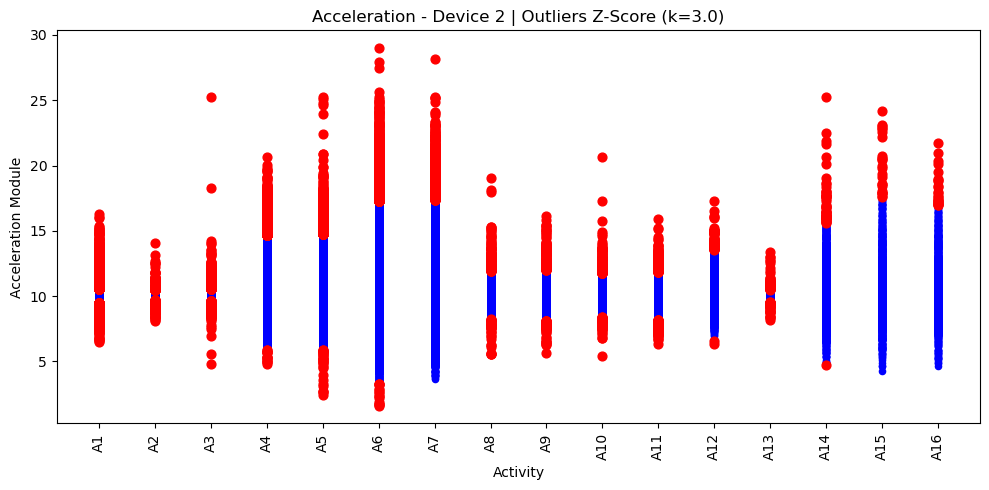

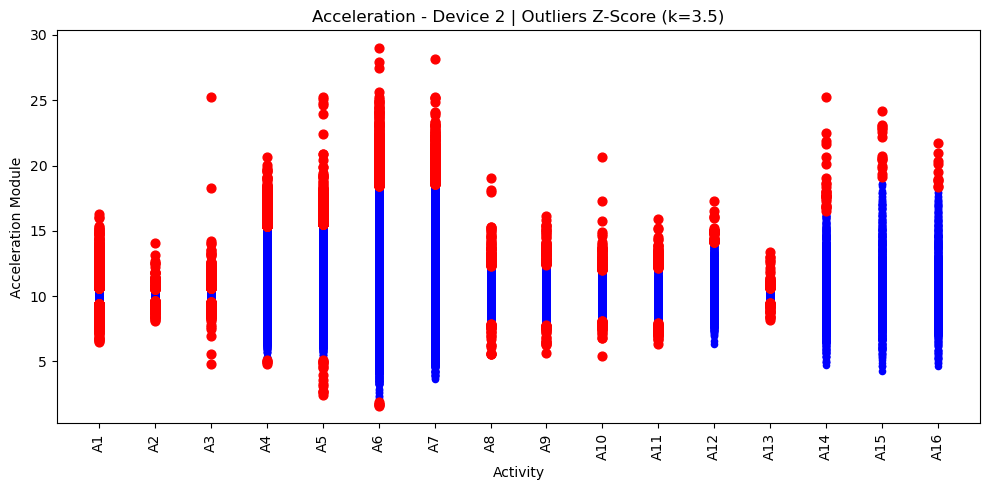

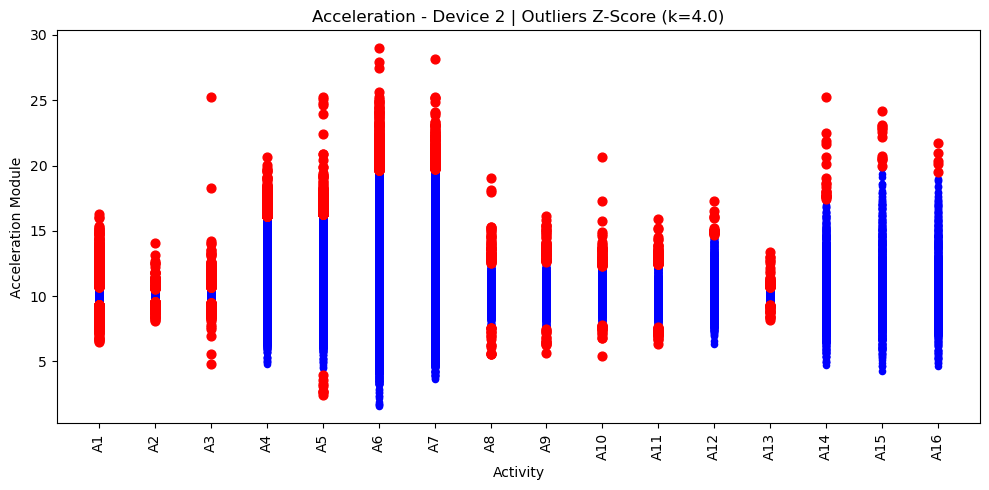

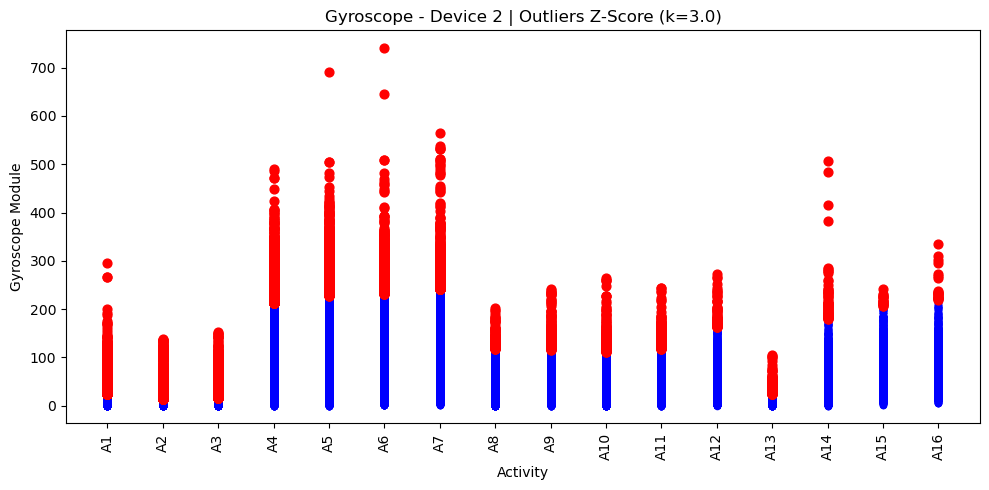

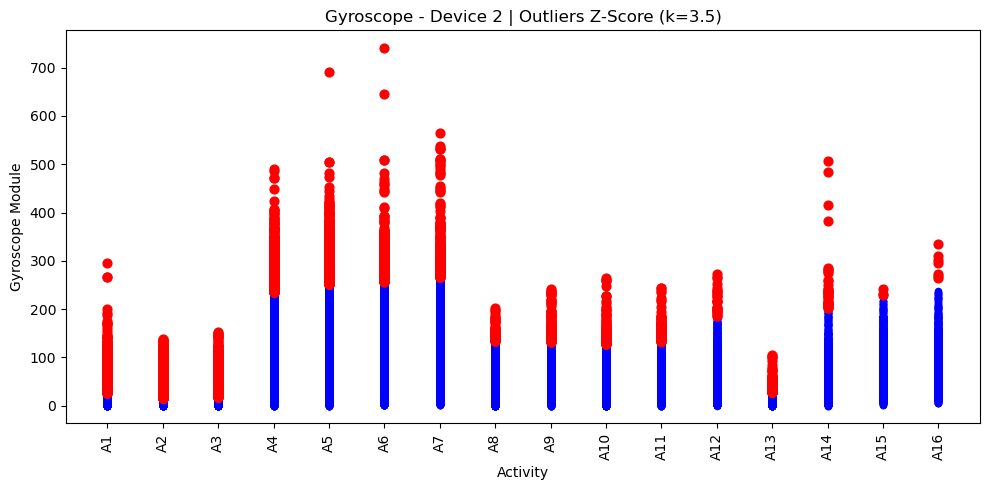

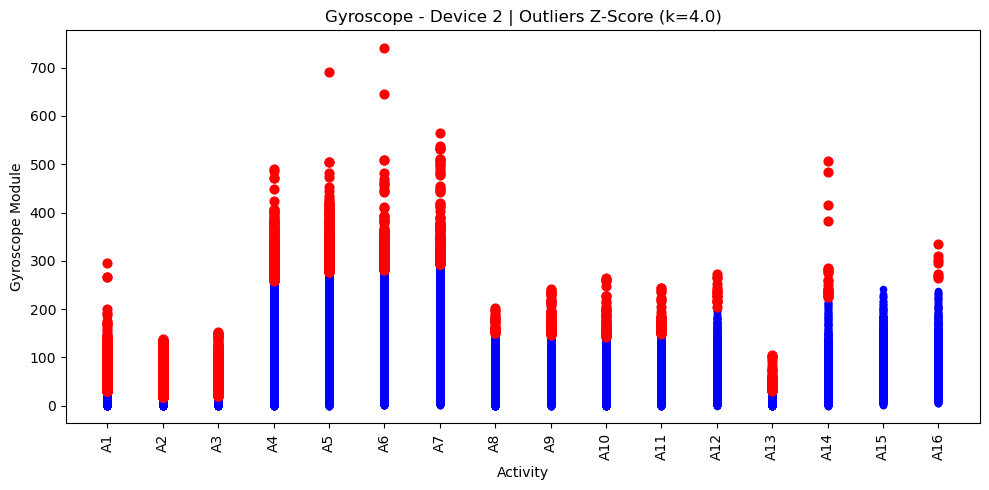

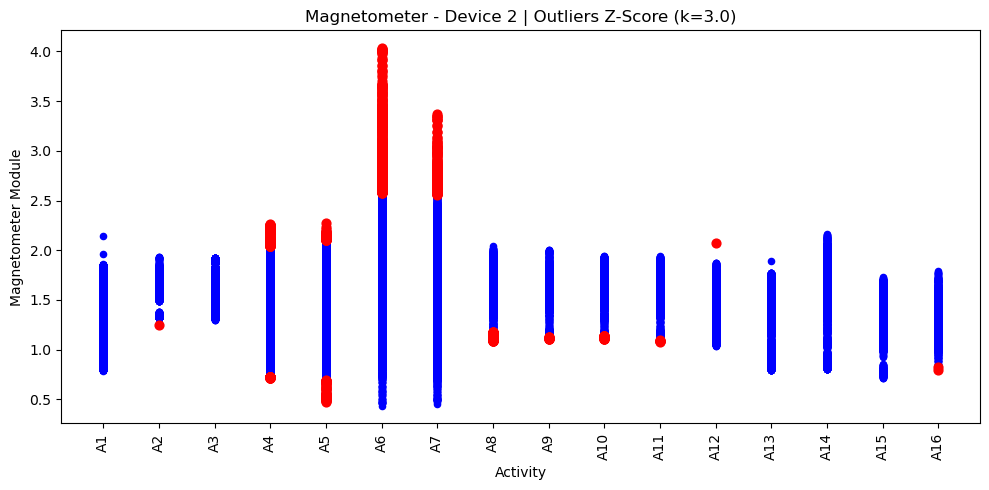

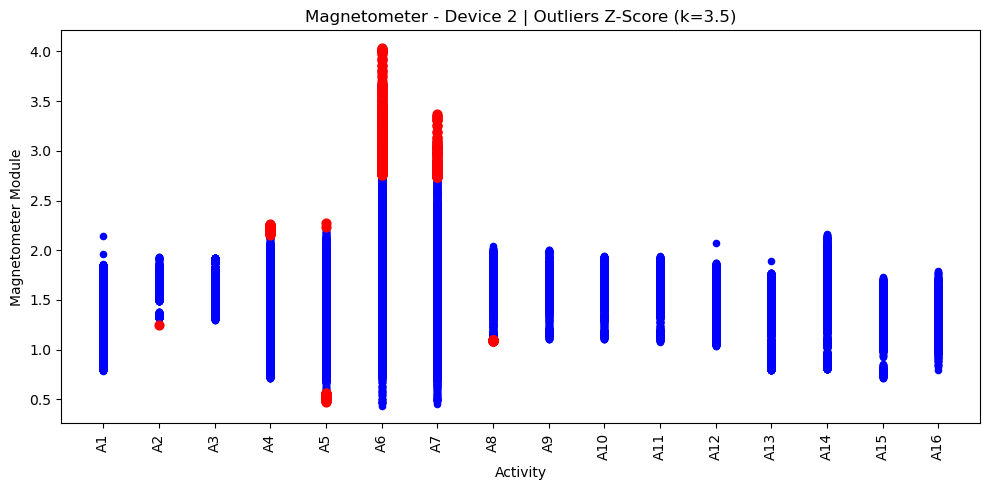

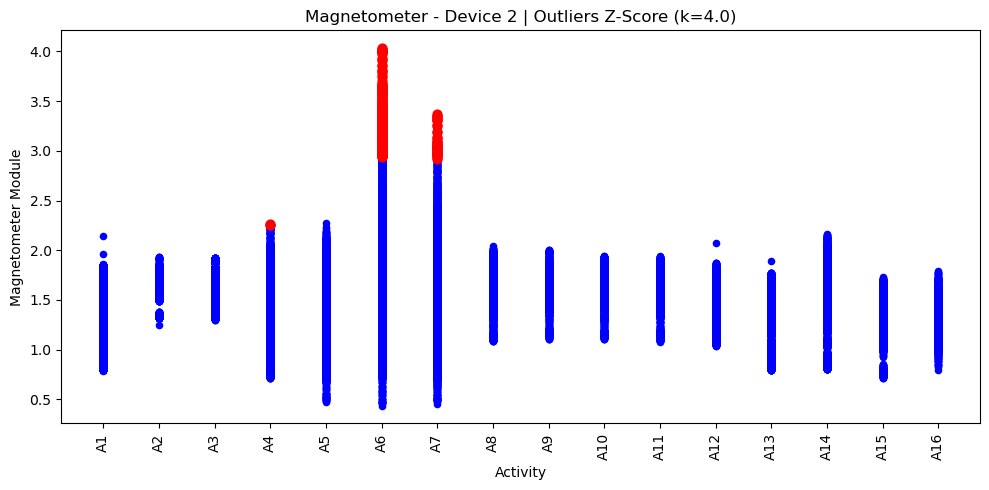

In [ ]:
device_target = 2  # pulso direito
mask_device = data[:, 1].astype(int) == device_target
data_right_wrist = data[mask_device]


module_boxplots(data_right_wrist, sensor=1)  # Aceleração
module_boxplots(data_right_wrist, sensor=2)  # Giroscópio
module_boxplots(data_right_wrist, sensor=3)  # Magnetômetro

print("=== Outliers Z-Score - Pulso Direito (Device 2) ===")
plot_zscore_outliers(data_right_wrist, sensor=1, k_values=[3.0, 3.5, 4.0])
plot_zscore_outliers(data_right_wrist, sensor=2, k_values=[3.0, 3.5, 4.0])
plot_zscore_outliers(data_right_wrist, sensor=3, k_values=[3.0, 3.5, 4.0])



## Observações:
  ### Geral:
- A comparação revela que atividades com maior variabilidade visual nos gráficos 3.1 correspondem a maior número de outliers nas análises 3.4.
- O método Z-Score é eficaz para identificar desvios extremos, mas pode ser excessivamente sensível para dados de movimento humano
- Há medida que o k aumenta, menos filtra os outliers
  ### Aceleração:
  #### Módulo Aceleração:
  - Atividades com maior variabilidade na 3.1 (como 8, 9, 10, 11, 12) mostram dispersão significativa entre dispositivos nos valores do módulo, o que se reflete em mais outliers na 3.4
  - Atividades com menor variabilidade na 3.1 (como 1, 2, 3, 4), apresentam padrões mais consistentes entre dispositivos e menor amplitude de variação, resultando em menos outliers na 3.4
  - Dispositivos como o 3 e o 4 mostram padrões consistentemente diferentes dos outros em múltiplas atividades nas 3.1, contribuindo para os outliers nas 3.4
  #### Conclusão:
  - A análise 3.4 com Z-Score valida quantitativamente as observações qualitativas das figuras 3.1
  - Atividades que visualmente mostram maior inconsistência entre dispositivos nas 3.1 são corretamente identificadas como tendo mais outliers na 3.4
  ### Giroscópio:
  #### Módulo Giroscópio:
  - 6 a 12 apresentam picos extremos de outliers na 3.4 indicando movimentos rotacionais intensos e complexos
  - 1 a 5 mostram baixíssima contagem de outliers (0-100), refletindo movimentos rotacionais básicos ou quase inexistentes
  - A transição abrupta entre 5 e 6 revela uma mudança drástica no padrão de movimento, passando de estabilidade para rotatividade intensa
  - 3 e 4 demonstram inconsistências marcantes nas atividades de maior intensidade rotacional (6-12), com trajetórias claramente divergentes dos outros dispositivos
  - A atividade 8 destaca-se pela ausência de dados do módulo na 3.1, sugerindo possíveis falhas de medição que se refletem na análise de outliers
  #### Conclusão:
  - O giroscópio gera muito mais outliers que outros sensores devido à natureza dos movimentos rotacionais
  ### Magnetómetro:
  #### Módulo Magnetómetro:
  - A consistência visual observada nas figuras 3.1, onde todos os dispositivos mostram trajetórias sobrepostas e padrões uniformes, reflete-se diretamente nos valores mínimos de outliers nas análises 3.4
  - 1 a 16 apresentam valores consistentemente baixos de outliers nas análises 3.4, com todos os valores abaixo de 0.5, indicando alta estabilidade nas medições
  - Não se observam picos significativos de outliers em nenhuma atividade específica, ao contrário do verificado nos outros sensores
  #### Conclusão:
  - O magnetómetro estabelece um padrão de referência para qualidade de dados, contra o qual podem ser comparados o desempenho do giroscópio e acelerómetro



### Exercício 3.6
Elabore uma rotina que implemente o algoritmo k-means para n (valor de entrada) clusters.
#### Explicação da rotina implementada:
A rotina implementada para o algoritmo k-means segue os passos:
1. Inicialização: São selecionados `n_clusters` centróides iniciais aleatoriamente a partir dos dados.
2. Atribuição: Cada ponto no dataset data é iterativamente comparado com todos os centróides atuais. A distância Euclidiana (np.linalg.norm) é calculada entre o ponto e cada centróide. O ponto é então atribuído ao cluster cujo centróide se encontra mais próximo (menor distância).
3. Atualização: Os centróides são recalculados como a média dos pontos atribuídos a cada cluster. Para evitar erros, se um cluster ficar temporariamente vazio (nenhum ponto atribuído), o seu centróide é re-inicializado aleatoriamente a partir do dataset original.
4. Convergência: Os passos de atribuição e atualização são repetidos. O algoritmo termina quando:
- A mudança na posição de todos os centróides entre uma iteração e a seguinte é muito pequena (inferior a uma tolerância `tol`).
- O número de repetições atinge o limite `max_iter`.

In [37]:
def kmeans (data, n_clusters, max_iter=100, tol=1e-4):
    centroids= data[np.random.choice(data.shape[0], n_clusters, replace=False)]
    
    for i in range(max_iter):
        labels = np.zeros(data.shape[0], dtype=int)
        
        # Passo 1: atribui cada ponto ao cluster mais próximo
        for i, point in enumerate(data):
            min_dist = float('inf')
            for k in range(n_clusters):
                dist = np.linalg.norm(point - centroids[k])
                if dist < min_dist:
                    min_dist = dist
                    labels[i] = k
                    
        # Passo 2: atualiza centróides
        new_centroids = np.zeros_like(centroids)
        for k in range(n_clusters):
            cluster_points = data[labels == k]
            if len(cluster_points) > 0:
                new_centroids[k] = cluster_points.mean(axis=0)
            else:
                # Se algum cluster ficar vazio, reposiciona aleatoriamente
                new_centroids[k] = data[np.random.choice(data.shape[0])]
        
        if np.all(np.linalg.norm(new_centroids - centroids, axis=1) < tol):
            break
        
        centroids = new_centroids
    
    return labels, centroids
            

## Exercício 3.7
Determine os outliers no dataset transformado usando o k-means. Experimente diferentes números de clusters e compare com os resultados obtidos em 3.4. Ilustre graficamente os resultados usando gráficos 3D para cada vetor
### Explicação da rotina implementada:
A função foi desenhada para aplicar o K-Means aos dados 3D de um sensor específico, identificar outliers com base na estrutura dos clusters formados e plotar os resultados em gráficos 3D.
A rotina segue os seguintes passos:
1. Filtragem dos dados: Começa por isolar os dados relevantes, filtrando o dataset pelo ID do dispositivo e, opcionalmente, por uma atividade específica.
2. Aplicação do K-Means: Para cada sensor (aceleração, giroscópio, magnetómetro), a função `kmeans` é chamada sobre os dados 3D para os agrupar em k_clusters.
3. Identificação de outliers:Para cada cluster, a função calcula o intervalo interquartil (IQR) do conjunto das suas distâncias. Um ponto é classificado como outlier se a asua distnância ao centróide for superior ao limite superior de Tukey (Q3 + 1.5 * IQR). Este método permite identificar pontos que estão significativamente afastados do centro do cluster.
4. Plotagem dos resultados: Finalmente, a função cria gráficos 3D para cada sensor, com clusters representados por cores diferentes para melhor visualizar os dados. Sendo que cada outlier é uma cruz da cor do cluster a que pertence e as centróides são representadas por estrelas pretas.


 K-Means com k=3 clusters - Activity 7


C:\Users\didia\AppData\Local\Temp\ipykernel_13996\3994112704.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', k_clusters)


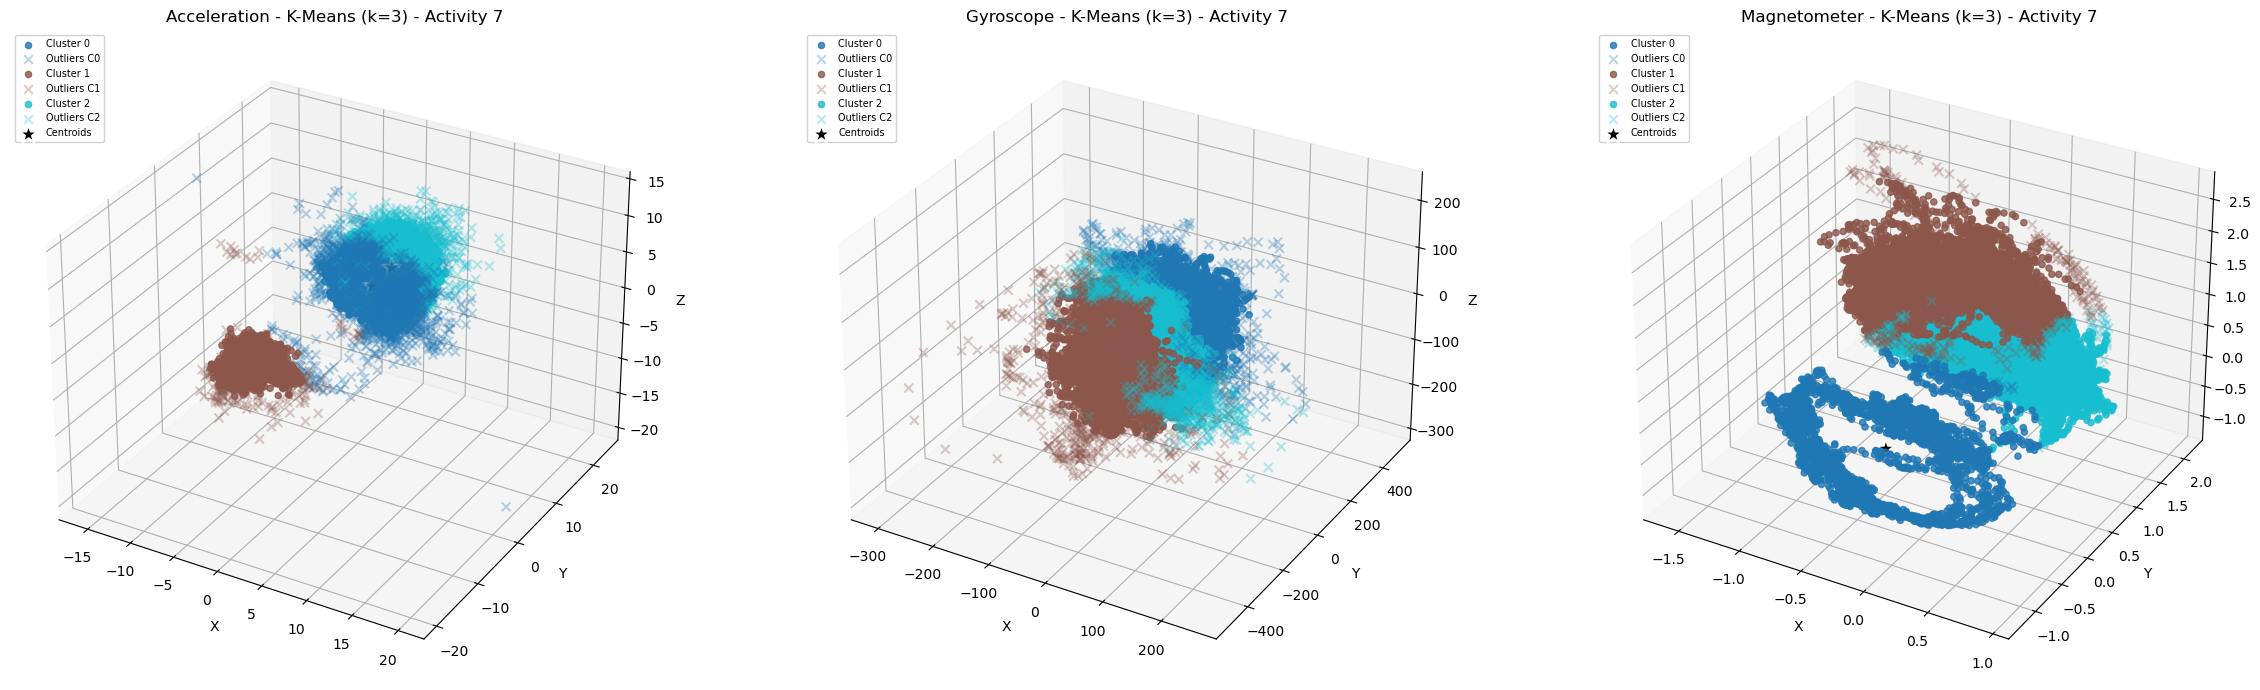

In [38]:
def kmeans_outliers_3d_horizontal(data, k_clusters, device_id=2, activity_filter=None):
    sensors = [1, 2, 3]
    labels_map = {1: 'Acceleration', 2: 'Gyroscope', 3: 'Magnetometer'}
    cols_map = {1: (2, 3, 4), 2: (5, 6, 7), 3: (8, 9, 10)}
    
    # Cria figura com 1 linha, 3 colunas
    fig = plt.figure(figsize=(24, 7))
    
    for idx, sensor in enumerate(sensors):
        ax = fig.add_subplot(1, 3, idx+1, projection='3d')
        
        label = labels_map[sensor]
        c = cols_map[sensor]
        
        # Filtra device
        device_data = data[data[:, 1] == device_id]
        
        # Filtra atividade (se especificado)
        if activity_filter is not None:
            device_data = device_data[device_data[:, 12] == activity_filter]
        
        sensor_data = device_data[:, c]
        
        if sensor_data.shape[0] == 0:
            ax.text(0.5, 0.5, 0.5, f"No data for {label}", ha='center')
            continue
        
        # Aplica k-means
        labels_kmeans, centroids = kmeans(sensor_data, k_clusters)
        colors = cm.get_cmap('tab10', k_clusters)
        
        title = f'{label} - K-Means (k={k_clusters})'
        if activity_filter is not None:
            title += f' - Activity {int(activity_filter)}'
        ax.set_title(title)
        
        # Plota cada cluster
        for cluster_id in range(k_clusters):
            cluster_points_idx = np.where(labels_kmeans == cluster_id)[0]
            if len(cluster_points_idx) == 0:
                continue
            
            cluster_points = sensor_data[cluster_points_idx]
            distances = np.linalg.norm(cluster_points - centroids[cluster_id], axis=1)
            
            Q1 = np.percentile(distances, 25)
            Q3 = np.percentile(distances, 75)
            IQR = Q3 - Q1
            upper_limit = Q3 + 1.5 * IQR
            
            
            outlier_mask = distances > upper_limit
            
            # Usar o bitwise NOT para obter os pontos normais através dos outliers
            normal_mask = ~outlier_mask
            
            normal_idx_local = cluster_points_idx[normal_mask]
            outlier_idx_local = cluster_points_idx[outlier_mask]
            
            cluster_color = colors(cluster_id)
            
            # Pontos normais
            if len(normal_idx_local) > 0:
                ax.scatter(sensor_data[normal_idx_local, 0],
                           sensor_data[normal_idx_local, 1],
                           sensor_data[normal_idx_local, 2],
                           color=cluster_color, s=20, alpha=0.8,
                           label=f'Cluster {cluster_id}')
            
            # Outliers
            if len(outlier_idx_local) > 0:
                ax.scatter(sensor_data[outlier_idx_local, 0],
                           sensor_data[outlier_idx_local, 1],
                           sensor_data[outlier_idx_local, 2],
                           color=cluster_color, s=40, alpha=0.3, marker='x',
                           label=f'Outliers C{cluster_id}')
        
        # Centróides
        ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
                   color='black', s=200, marker='*', edgecolors='white', linewidths=1.5,
                   label='Centroids', zorder=10)
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.legend(loc='upper left', fontsize=7, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

# Execução
k_val = 3
print(f"\n K-Means com k={k_val} clusters - Activity 7")
kmeans_outliers_3d_horizontal(data, k_clusters=k_val, device_id=2, activity_filter=7)

### Observações
Para facilitar a computação foram utilizados apenas os dados do sensor do pulso direito (device 2) e foi analisada a atividade 7.
#### Análise dos Gráficos K-Means (Exercício 3.7)
Foi aplicado o algoritmo K-Means aos dados 3D (x, y, z) de cada sensor e o método de deteção de outliers foi baseado no método IQR das distâncias de cada ponto ao seu centróide de cluster.
##### Escolha do k = 3:
O enunciado pedia para "experimentar diferentes números de clusters". Após experimentarmos diferentes valores, k = 3 foi escolhido por ser o valor que melhor parece capturar a estrutura natural dos dados para a atividade 7.
- Utilizar um k mais baixo forçaria a junção de clusters distintos, o que pode dar origem a falsos positivos e um k mais alto resultaria em clusters muito pequenos, o que não é representativo.
##### Observações por Sensor:
- **Aceleração**: O gráfico mostra três clusters de dados muito distintos, ou seja, o k-means conseguiu segmentar estes três sub-movimentos de forma eficaz.
- **Giroscópio**: Da mesma forma, os dados do giroscópio também se agrupam em três clusters distintos.
- **Magnetómetro**: Os dados formam três arcos distintos no espaço, que o k-means conseguiu identificar.

#### Comparação entre Z-Score e K-Means
##### Natureza da deteção:
- O Z-Score encontra pontos com magnitude extrema. Um ponto com módulo 40 é um outlier independentemente de ter vindo de (40, 0, 0) ou (23.1, 23.1, 23.1).
- O K-Means encontra pontos estruturalmente anómalos. Um ponto pode ter uma magnitude alta mas se estiver dentro de um cluster de outros pontos com magnitudes semelhantes, não será um outlier.
##### Quantidade dos outliers:
- O Z-Score marca uma enorme percentagem dos dados em atividades dinâmicas como outliers. É provável que esteja a gerar muitos falsos positivos, marcando picos normais do movimento como anómalos.
- O K-Means é mais "inteligente". Ao encontrar primeiro os clusters de movimento, ele define o que é normal com base na forma 3D do movimento. Os outliers identificados são muito menos numerosos e é mais provável que sejam verdadeiros anómalos.
### Conclusão
O método K-Means aplicado aos dados 3D é uma abordagem mais robusta para este problema. Utiliza o contexto da estrutura do movimento para definir o que é anómalo. O Z-Score, sendo um método univariado aplicado ao módulo, perde todo esse contexto e acaba por classificar incorretamente picos de alta magnitude como outliers.

### Exercício 3.7.1 (Bónus)
Poderá realizar um estudo análogo usando o algoritmo DBSCAN (sugere-se que recorra à [biblioteca sklearn2](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html#sklearn.cluster.DBSCAN))

Encontrados 7 clusters e 183 outliers no Acceleration


C:\Users\didia\AppData\Local\Temp\ipykernel_13996\357501071.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', n_clusters)


Encontrados 29 clusters e 43638 outliers no Gyroscope


C:\Users\didia\AppData\Local\Temp\ipykernel_13996\357501071.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', n_clusters)


Encontrados 1 clusters e 0 outliers no Magnetometer


...

C:\Users\didia\AppData\Local\Temp\ipykernel_13996\357501071.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', n_clusters)


Encontrados 5 clusters e 43776 outliers no Gyroscope


C:\Users\didia\AppData\Local\Temp\ipykernel_13996\357501071.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', n_clusters)


Encontrados 1 clusters e 0 outliers no Magnetometer


C:\Users\didia\AppData\Local\Temp\ipykernel_13996\357501071.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', n_clusters)
C:\Users\didia\AppData\Local\Temp\ipykernel_13996\357501071.py:64: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


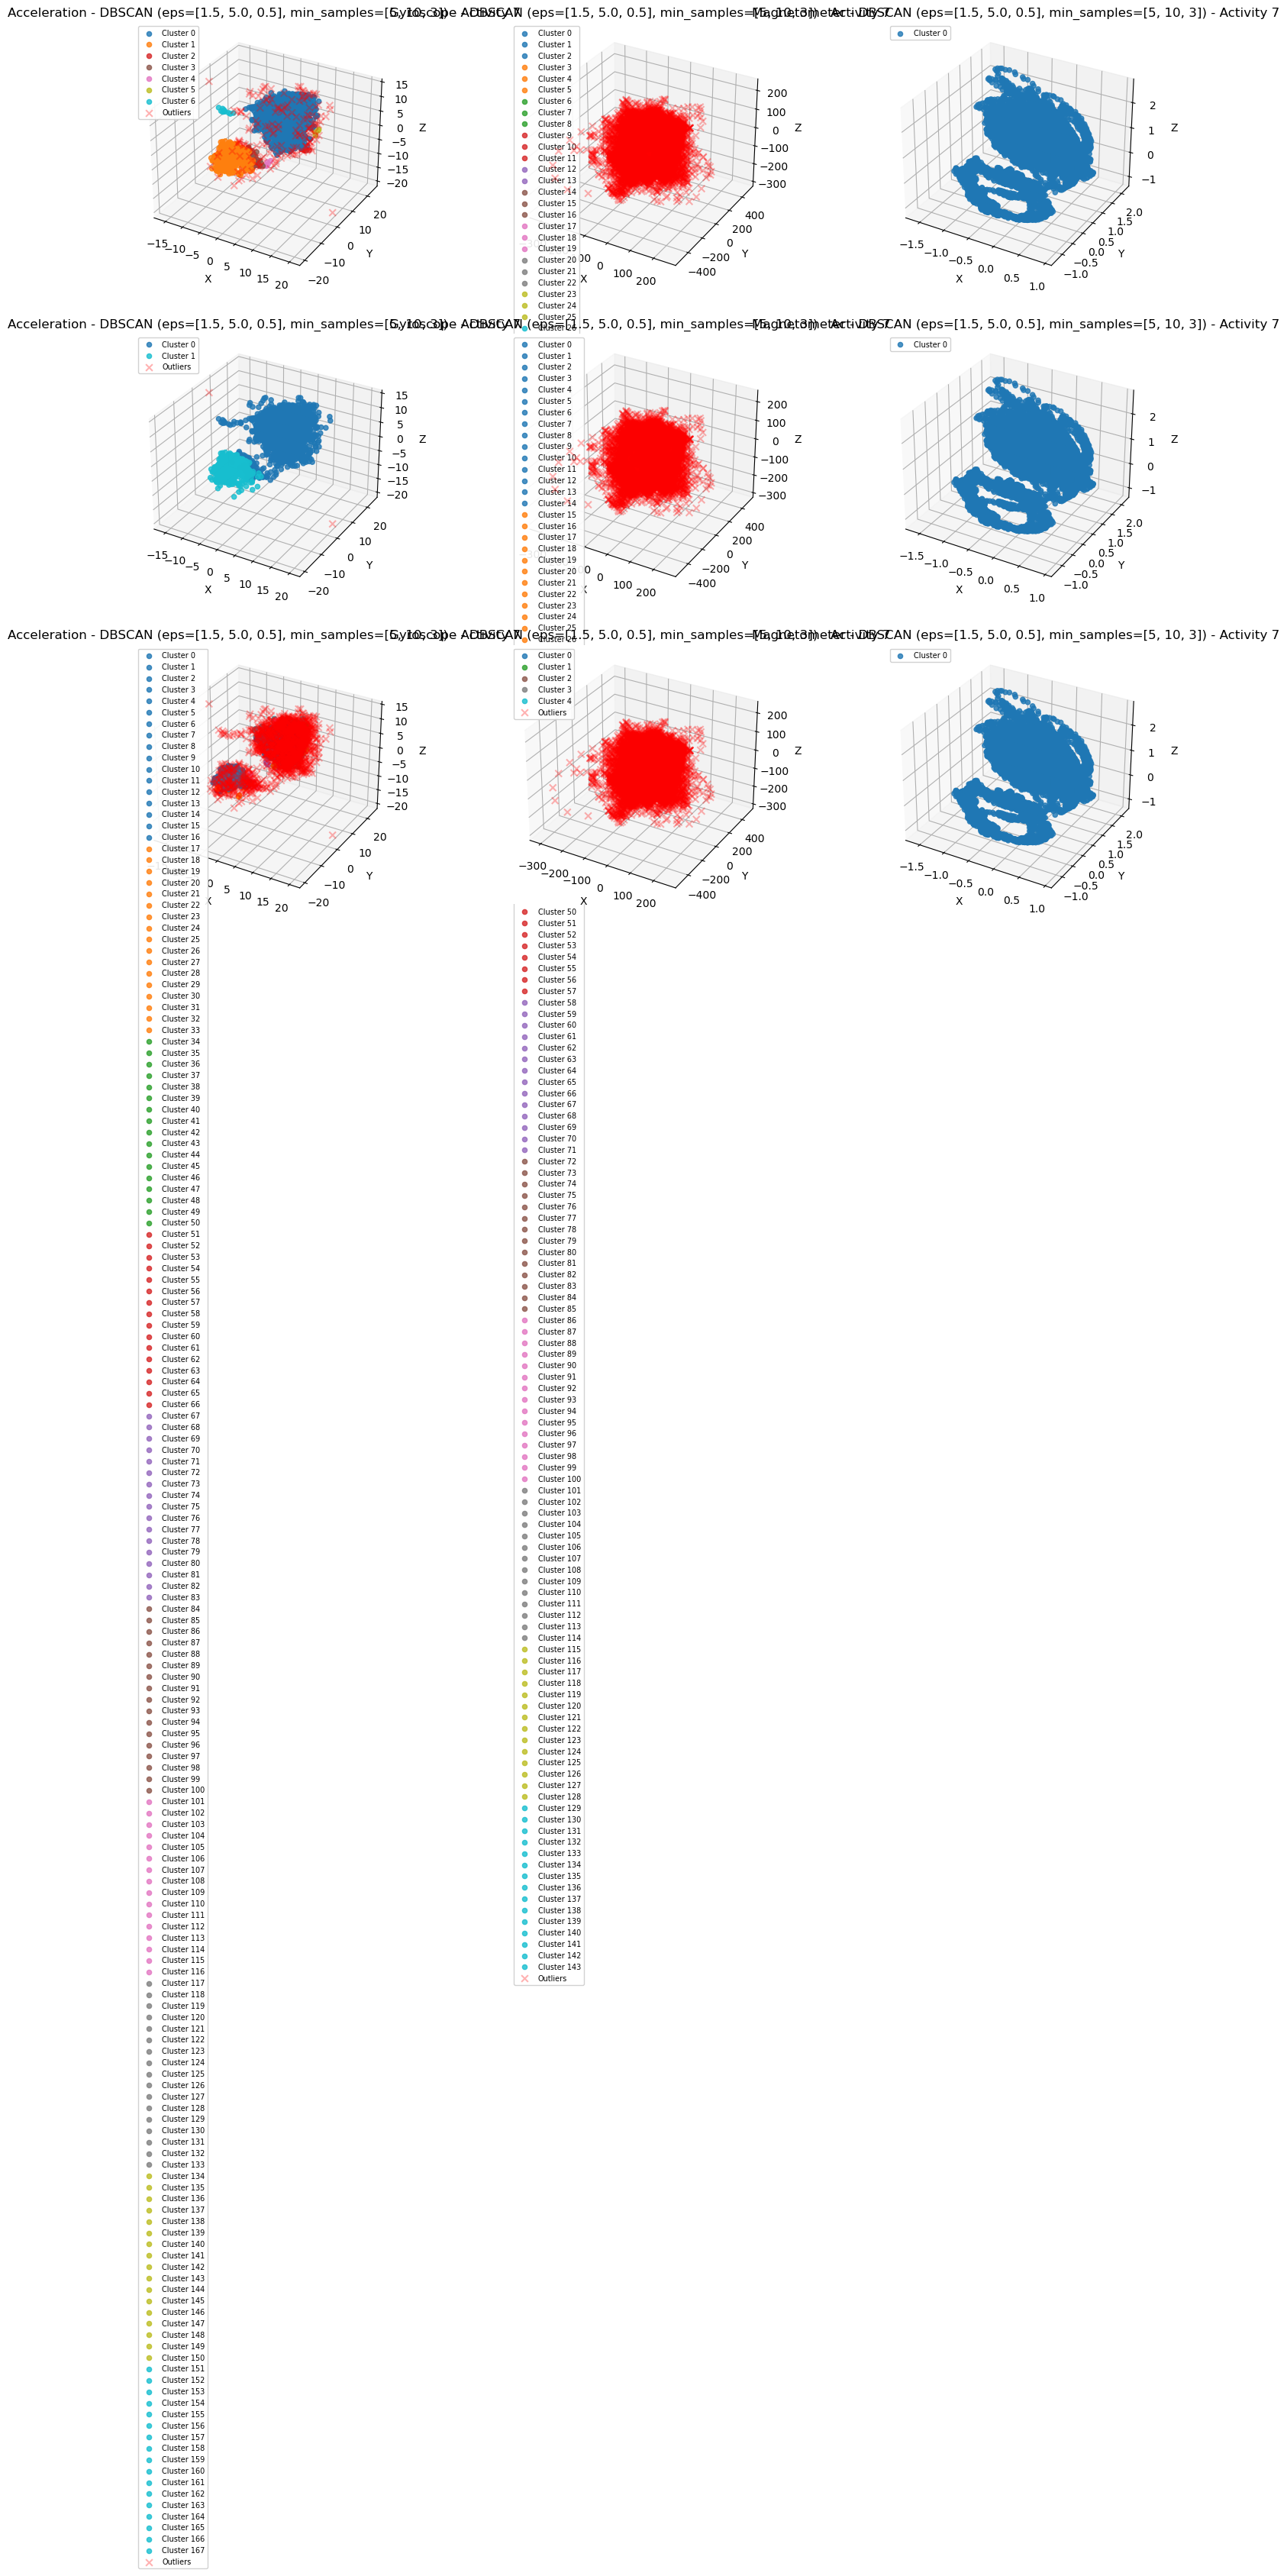

In [43]:
from sklearn.cluster import DBSCAN

def dbscan_outliers_3d(data, eps, min_samples, device_id=2, activity_filter=None):
    sensors = [1, 2, 3]
    labels_map = {1: 'Acceleration', 2: 'Gyroscope', 3: 'Magnetometer'}
    cols_map = {1: (2, 3, 4), 2: (5, 6, 7), 3: (8, 9, 10)}
    
    n_cols = 3
    n_rows = len(eps)

    fig = plt.figure(figsize=(6 * n_cols , 5 * n_rows))
    for row_idx, (eps_value, min_samples_value) in enumerate(zip(eps, min_samples)):
        for col_idx, sensor in enumerate(sensors):
            ax = fig.add_subplot(n_rows, n_cols, row_idx * n_cols + col_idx + 1, projection='3d')
            label = labels_map[sensor]
            c = cols_map[sensor]

            # Filtrar device e atividade
            device_data = data[data[:, 1] == device_id]
            if activity_filter is not None:
                device_data = device_data[device_data[:, 12] == activity_filter]
            sensor_data = device_data[:, c]

            if (sensor_data.shape[0] == 0):
                ax.set_title(f"{label} - No data available")
                continue
            db = DBSCAN(eps=eps_value, min_samples=min_samples_value)
            labels = db.fit_predict(sensor_data)

            # Outliers
            outliers_index = np.where(labels == -1)[0]
            unique_cluster_labels = set(labels) - {-1}
            n_clusters = len(unique_cluster_labels)
            n_noise = len(outliers_index)
            print("Encontrados %d clusters e %d outliers no %s" % (n_clusters, n_noise, label))

            title = f"{label} - DBSCAN (eps={eps}, min_samples={min_samples})"
            if activity_filter is not None:
                title += f" - Activity {int(activity_filter)}"
            ax.set_title(title)

            colors = cm.get_cmap('tab10', n_clusters)

            if n_clusters > 0:
                for cluster_id in unique_cluster_labels:
                    cluster_points_idx = np.where(labels == cluster_id)[0]
                    cluster_color = colors(cluster_id)

                    ax.scatter(sensor_data[cluster_points_idx, 0],
                               sensor_data[cluster_points_idx, 1],
                               sensor_data[cluster_points_idx, 2],
                               color=cluster_color, s=20, alpha=0.8,
                               label=f'Cluster {cluster_id}')
            if n_noise > 0:
                ax.scatter(sensor_data[outliers_index, 0],
                           sensor_data[outliers_index, 1],
                           sensor_data[outliers_index, 2],
                           color='red', s=40, alpha=0.3, marker='x',
                           label='Outliers')
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_zlabel('Z')
            ax.legend(loc='upper left', fontsize=7, framealpha=0.9)
    plt.tight_layout()
    plt.show()

# Execução
eps_values = [1.5, 5.0, 0.5]
min_samples_values = [5, 10, 3]
dbscan_outliers_3d(data, eps=eps_values, min_samples=min_samples_values, device_id=2, activity_filter=7)


### Observações
Após utilizar o DBSCAN com os parametros eps=1.5 e min_samples=5, ficou clara a sensibilidade do algoritmo a estes parâmetros.
- Com estes parâmetros, o DBSCAN, não funciona bem para todos os sensores:
    - **Aceleração(7 clusters, 183 outliers)**: Foi o resultado mais razoável. O número de clusters encontrados pode refletir a atividade realizada e o número de outliers não é zero mas também não é excessivo.
    - **Giroscópio(29 clusters, 43638 outliers)**: O resultado não é satisfatório. O número de outliers é extremamente elevado, indicando que o eps é demasiado pequeno para a densidade dos dados. O número elevado de clusters também sugere que o eps é pequeno, fazendo com que pequenas densidades sejam consideradas clusters distintos. 
    - **Magnetómetro(1 cluster, 0 outliers)**: Este resultado pode indicar o oposto. Parâmetros demasiado grandes, que fizeram com que todos os pontos fossem agrupados num único cluster ou os dados são excecionalmente uniformes e sem pontos ruidosos.
### Ajuste dos Parâmetros
O próximo passo foi ajustar os parâmetros eps e min_samples para obtermos um resultado adequado para cada sensor. Após alguns testes, os seguintes parâmetros foram escolhidos:
- **Aceleração**: eps=1.5, min_samples=5
- **Giroscópio**: eps=5.0, min_samples=10
- **Magnetómetro**: eps=0.5, min_samples=3

## Exercício 4
Extração de informação característica: o objetivo será comprimir o espaço do problema,
extraindo informação característica discriminante que permita implementar soluções
eficazes do problema de classificação.

### Exercício 4.1
Usando as variáveis aplicadas na alínea 3.1, determine a significância
estatística dos seus valores médios nas diferentes atividades. Observe que
poderá aferir a normalidade da distribuição usando, por exemplo, o teste Kolmogorov-Smirnov (ver documentação do SciPy). Para rever a escolha de
testes estatísticos sugere-se a referência. Comente

In [40]:
import numpy as np
from scipy.stats import kstest, shapiro, norm, f_oneway, kruskal

def module_significance(data, sensor, alpha=0.05):
    if sensor == 1:
        c = (2,3,4)
        label = 'Acceleration'
    elif sensor == 2:
        c = (5,6,7)
        label = 'Gyroscope'
    elif sensor == 3:
        c = (8,9,10)
        label = 'Magnetometer'
    else:
        raise ValueError("sensor must be 1, 2 ou 3")

    mod = np.sqrt((data[:, c]**2).sum(axis=1))
    activities = data[:, 12].astype(int)
    unique_activities = np.unique(activities)

    # Teste de normalidade
    all_normal = True
    for act in unique_activities:
        sample = mod[activities == act]
        mean_sample = np.mean(sample)
        std_sample = np.std(sample)

        # Kolmogorov–Smirnov
        stat_ks, p_ks = kstest(sample, 'norm', args=(mean_sample, std_sample))
        if p_ks <= alpha:
            all_normal = False

        # Shapiro–Wilk
        stat_sw, p_sw = shapiro(sample)
        if p_sw <= alpha:
            all_normal = False

    # Preparar amostras por atividade
    samples = [mod[activities == act] for act in unique_activities]

    # Escolher o teste estatístico
    if all_normal:
        stat_anova, p_value = f_oneway(*samples)
        test_name = "ANOVA (paramétrico)"
    else:
        stat_kruskal, p_value = kruskal(*samples)
        test_name = "Kruskal–Wallis (não-paramétrico)"

    # Mostrar resultado
    print(f"\n{label} — {test_name}")
    print(f"p-value = {p_value:.4e}")
    if p_value <= alpha:
        print("Rejeito H0")
    else:
        print("Aceito H0")


In [41]:
module_significance(data, sensor=1) 
module_significance(data, sensor=2) 
module_significance(data, sensor=3)  


c:\Users\didia\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")



Acceleration — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0

Gyroscope — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0

Magnetometer — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0


### Observações
#### Geral:

- Foram analisados os módulos dos sensores para todas as atividades, comparando os valores médios entre elas
- Para decidir o teste apropriado, foi verificada a normalidade de cada atividade usando Kolmogorov–Smirnov e Shapiro–Wilk. Nenhuma das atividades apresentou distribuição normal, justificando o uso do teste não-paramétrico Kruskal–Wallis.
- Os p-values obtidos foram praticamente zero para todos os sensores, indicando que as diferenças observadas entre atividades não ocorrem por acaso.

##### Acceleration:
Teste de Significância:
- Kruskal–Wallis: p-value ≈ 0
- Decisão: Rejeita-se H₀.
##### Observação: 
Há diferenças estatisticamente significativas nos valores médios do módulo de aceleração entre as atividades. Atividades dinâmicas apresentam valores médios mais elevados que as estáticas, refletindo variações reais de movimento.

##### Gyroscope:
Teste de Significância:
- Kruskal–Wallis: p-value ≈ 0
- Decisão: Rejeita-se H₀.
##### Observação: 
Os valores médios do giroscópio diferem significativamente entre as atividades. Atividades sem movimento apresentam módulo próximo de zero, enquanto atividades com movimento apresentam valores mais elevados, captando claramente a rotação do corpo.

##### Magnetometer:
Teste de Significância:
- Kruskal–Wallis: p-value ≈ 0
- Decisão: Rejeita-se H₀.
##### Observação: 
As diferenças nos valores médios do magnetómetro também são estatisticamente significativas. Contudo, a distinção entre atividades não é tão nítida quanto nos outros sensores. É possível que outliers relacionados com interferências magnéticas (ex.: estruturas metálicas) influenciem os resultados.

#### Conclusão:
- Todos os sensores apresentam diferenças significativas entre as atividades, confirmando que os valores médios dos módulos dos sensores podem ser usados para diferenciar atividades humanas.
- O Kruskal–Wallis mostrou-se adequado devido à ausência de normalidade nos dados.
- Em termos práticos, aceleração e giroscópio são mais discriminativos entre atividades, enquanto o magnetómetro pode ser útil em situações específicas, como detectar ambientes com interferência magnética ou movimentos de escada.

### Exercício 4.2

Desenvolva as rotinas necessárias à extração do feature set temporal e 
espectral sugerido no artigo4. Para o efeito deverá: 
- Ler o artigo e identificar o conjunto de features temporais e espectrais 
identificadas por estes autores. 
- Considere apenas janelas temporais (sliding windows) de 5 segundos, 
com overlap de 50% para segmentar os dados para a extração de 
features. Se um segmento cobrir mais do que uma atividade, descarte 
esse segmento. Ver em particular a Figura 2 e Tabela 1 do artigo1. 
- Para cada feature deverá elaborar uma rotina para a respetiva extração.  
- Usando as rotinas elaboradas no item anterior, deverá escrever o código 
necessário para extrair o vetor de features em cada instante. 

1ºpasso: dividir os dados em janelas de 5 segundos com 50% de overlap

In [45]:
def create_windows(data, window_length=5.0, overlap=0.5):
    timestamps = data[:, 11]
    step = window_length * (1 - overlap)
    
    # Gera todas as janelas de uma vez
    window_starts = np.arange(timestamps[0], timestamps[-1] - window_length + step, step)
    window_ends = window_starts + window_length
    
    # Encontra índices para cada janela
    start_indices = np.searchsorted(timestamps, window_starts)
    end_indices = np.searchsorted(timestamps, window_ends)
    
    windows = []
    for start_idx, end_idx in zip(start_indices, end_indices):
        if start_idx < end_idx:
            window_data = data[start_idx:end_idx]
            labels = window_data[:, 12]
            
            # Verificação rápida de uniformidade
            if labels[0] == labels[-1] and np.all(labels == labels[0]):
                windows.append(window_data)
    
    return windows

In [46]:
create_windows(data, window_length=5.0, overlap=0.5)

[array([[ 0.0000e+00,  1.0000e+00, -1.8650e+00,  9.3890e+00,  2.5812e+00,
         -1.1418e+00, -1.1856e+00,  8.4998e-01, -3.4476e-01,  5.9839e-01,
          1.0134e+00,  5.0589e+02,  1.0000e+00]]),
 array([[ 0.0000e+00,  1.0000e+00, -1.7963e+00,  9.3742e+00,  2.4460e+00,
         -1.5618e+00, -6.6165e-01,  5.9730e-01, -3.4274e-01,  5.7631e-01,
          1.0000e+00,  5.2542e+02,  1.0000e+00]]),
 array([[ 0.0000e+00,  1.0000e+00, -1.7963e+00,  9.3742e+00,  2.4460e+00,
         -1.5618e+00, -6.6165e-01,  5.9730e-01, -3.4274e-01,  5.7631e-01,
          1.0000e+00,  5.2542e+02,  1.0000e+00]]),
 array([[ 0.0000e+00,  1.0000e+00, -1.8696e+00,  9.3000e+00,  2.3514e+00,
         -1.1877e+00, -1.2841e+00,  1.4212e-01, -3.4476e-01,  5.9639e-01,
          1.0156e+00,  5.4495e+02,  1.0000e+00]]),
 array([[ 0.0000e+00,  1.0000e+00, -1.8696e+00,  9.3000e+00,  2.3514e+00,
         -1.1877e+00, -1.2841e+00,  1.4212e-01, -3.4476e-01,  5.9639e-01,
          1.0156e+00,  5.4495e+02,  1.0000e+00]]),
 arra

## FEATURES TEMPORAIS

MEAN

MEDIAN

STD

VARIANCE

ROOT MEAN SQUARE

AVERAGE DERIVATES

SKEWNESS

KURTOSIS

IQR

ZERO CROSSING RATE

MEAN CROSSING RATE

PAIRWISE CORRELATION

MOVEMENT INTENSITY

SIGNAL MAGNITUDE AREA

EIGENVALUES OF DOMINANT DIRECTIONS

CORRELATIONS ACCELERATION GRAVITY VS HEADING

AVERAGED VELOCITY GRAVITY

AVERAGED ROTATION ANGLES GRAVITY

## FEATURES ESPECTRAIS

SPECTRAL ENTROPY

DOMINANT FREQUENCY

AVERAGED ACCELERATION ENERGY

AVERAGED ROTATION ENERGY

### Exercício 4.3
Desenvolva o código necessário para implementar o PCA de um feature set;
poderá usar implementações existentes.

### Exercício 4.4
Determine a importância de cada vetor principal na explicação da
variabilidade do espaço de features. Note que deverá normalizar as features
usando o z-score. Quantas dimensões deverá usar para explicar 75% do
feature set?

#### Exercício 4.4.1.
Indique como poderia obter as features relativas a esta compressão e exemplifique para um instante à sua escolha.

#### Exercicio 4.4.2.
Indique as vantagens e as limitações desta abordagem.

### Exercício 4.5
Desenvolva o código necessário para implementar o Fisher feature Score e o ReliefF. Poderá usar implementações existentes.

### Exercício 4.6.
Identifique as 10 melhores features de acordo com o Fisher Score e o ReliefF e compare os resultados.

### Exercício 4.6.1.
Indique como poderia obter as features relativas a esta compressão e exemplifique para um instante à sua escolha.

### Exercício 4.6.2.
Indique as vantagens e as limitações desta abordagem.